La **Regressione Lineare** è, tecnicamente parlando, la "nonna" di tutti gli algoritmi di apprendimento supervisionato. Nonostante la sua semplicità, rimane uno degli strumenti più potenti per l'interpretabilità dei dati.

---

### 1. L'Equazione Fondamentale

A livello matematico, l'obiettivo è trovare una relazione funzionale che descriva il target  (il prezzo della casa) come una combinazione lineare delle feature  (superficie, qualità, ecc.).

L'equazione per un singolo esempio è:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon$$

Dove:

* $y$ : È la **variabile dipendente** (il target log-trasformato).
* $\beta_0$ : È l'**intercetta** (il valore di  quando tutte le  sono zero).
* $\beta_1, \dots, \beta_n$ : Sono i **coefficienti** (o pesi). Indicano di quanto varia  per ogni variazione unitaria della relativa .
* $\epsilon$ : È il **termine di errore** (residuo), che rappresenta tutto ciò che il modello non riesce a spiegare.

In notazione matriciale, più elegante per i calcoli computazionali, la scriviamo come:

$$\hat{y} = X\beta$$

---

### 2. La Funzione di Costo: OLS (Ordinary Least Squares)

Come decidiamo quali sono i "migliori" ? Usiamo il metodo dei **Minimi Quadrati Ordinari**. Il modello cerca di minimizzare la somma dei quadrati delle differenze tra i valori reali () e quelli predetti ().

La funzione di costo (Mean Squared Error) è:

$$J(\beta) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Perché al quadrato?**

1. Per rendere tutti gli errori positivi (non vogliamo che un errore di  e uno di  si cancellino a vicenda).
2. Per penalizzare maggiormente gli **errori grandi**: un errore doppio pesa quattro volte di più. Ecco perché la regressione lineare è così sensibile agli outlier!

---

### 3. Le Assunzioni (Livello Avanzato)

Affinché i risultati di una regressione lineare siano affidabili (e non solo "numeri a caso"), la teoria statistica richiede che siano soddisfatti alcuni requisiti:

* **Linearità:** La relazione tra variabili e target deve essere effettivamente lineare.
* **Indipendenza degli errori:** Non deve esserci correlazione tra i residui.
* **Omoschedasticità:** La varianza dell'errore deve essere costante. Se l'errore aumenta al crescere del prezzo della casa, abbiamo un problema (eteroschedasticità).
* **Normalità dei residui:** Gli errori dovrebbero distribuirsi secondo una curva a campana (ecco perché abbiamo fatto la log-transform sul prezzo!).

---

### 4. Come si trovano i $\beta$?

Esistono due strade principali:

1. **Equazione Normale:** Una soluzione analitica diretta $\beta = (X^T X)^{-1} X^T y$. È veloce per dataset piccoli ma diventa computazionalmente pesante se abbiamo migliaia di feature.
2. **Gradient Descent (Discesa del Gradiente):** Un algoritmo iterativo che "scende" lungo la curva della funzione di costo finché non trova il punto di minimo. È lo standard per i Big Data e il Deep Learning.



<>:45: SyntaxWarning: invalid escape sequence '\e'
<>:48: SyntaxWarning: invalid escape sequence '\h'
<>:45: SyntaxWarning: invalid escape sequence '\e'
<>:48: SyntaxWarning: invalid escape sequence '\h'


--- Risultati del Modello ---
Intercetta vera (β0): 5 | Stima del modello (β0^): 5.65
Pendenza vera (β1):   2.5 | Stima del modello (β1^): 2.36
------------------------------


C:\Users\mbagn\AppData\Local\Temp\ipykernel_27940\3709616343.py:45: SyntaxWarning: invalid escape sequence '\e'
  plt.scatter(X_synthetic, y_synthetic, color='blue', alpha=0.6, label='Dati Osservati (con Rumore $\epsilon$)')
C:\Users\mbagn\AppData\Local\Temp\ipykernel_27940\3709616343.py:48: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(X_plot, y_plot, color='red', linewidth=3, label=f'Retta OLS: $\hat{{y}} = {beta_0_hat:.2f} + {beta_1_hat:.2f}x$')


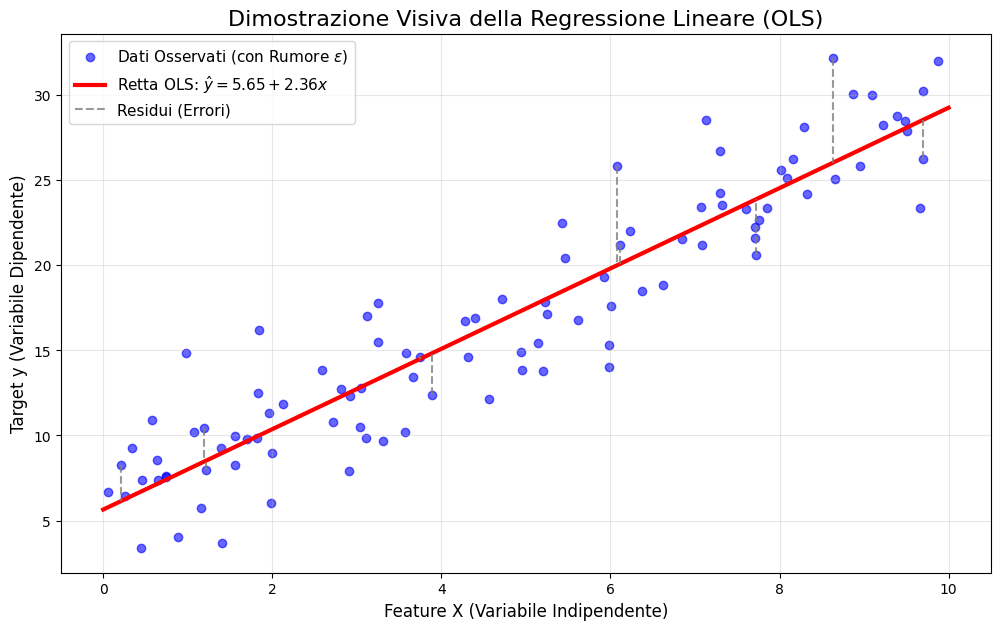

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# --- 1. GENERAZIONE DATI SINTETICI ---
np.random.seed(42) # Per riproducibilità

n_samples = 100
# Generiamo 100 punti X casuali tra 0 e 10
X_synthetic = 10 * np.random.rand(n_samples, 1)

# Definiamo i parametri "veri" nascosti
true_beta_0 = 5   # Intercetta vera
true_beta_1 = 2.5 # Pendenza vera (coefficiente angolare)

# Generiamo il rumore (epsilon): distribuzione normale con deviazione standard 3
noise = np.random.randn(n_samples, 1) * 3

# Generiamo il target y osservato: relazione lineare + rumore
y_synthetic = true_beta_0 + (true_beta_1 * X_synthetic) + noise


# --- 2. ADDESTRAMENTO DEL MODELLO ---
model_demo = LinearRegression()
model_demo.fit(X_synthetic, y_synthetic)

# Estraiamo i parametri che il modello ha imparato dai dati rumorosi
beta_0_hat = model_demo.intercept_[0]
beta_1_hat = model_demo.coef_[0][0]

print(f"--- Risultati del Modello ---")
print(f"Intercetta vera (β0): {true_beta_0} | Stima del modello (β0^): {beta_0_hat:.2f}")
print(f"Pendenza vera (β1):   {true_beta_1} | Stima del modello (β1^): {beta_1_hat:.2f}")
print("-" * 30)


# --- 3. VISUALIZZAZIONE ---
# Creiamo una linea liscia per il grafico della predizione
X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
y_plot = model_demo.predict(X_plot)

plt.figure(figsize=(12, 7))

# a) I dati osservati (la nuvola di punti)
plt.scatter(X_synthetic, y_synthetic, color='blue', alpha=0.6, label='Dati Osservati (con Rumore $\epsilon$)')

# b) La retta di regressione imparata dal modello
plt.plot(X_plot, y_plot, color='red', linewidth=3, label=f'Retta OLS: $\hat{{y}} = {beta_0_hat:.2f} + {beta_1_hat:.2f}x$')

# c) Visualizzazione dei RESIDUI (gli errori che OLS minimizza)
# Disegniamo delle linee verticali tra alcuni punti e la retta
for i in range(0, n_samples, 10): # Ne mostriamo uno ogni 10 per chiarezza
    x_point = X_synthetic[i]
    y_point = y_synthetic[i]
    y_pred_point = model_demo.predict(x_point.reshape(-1,1))
    plt.vlines(x_point, y_point, y_pred_point, colors='gray', linestyles='--', alpha=0.8)
    if i == 0: # Aggiungiamo la label solo una volta per la legenda
         plt.vlines(x_point, y_point, y_pred_point, colors='gray', linestyles='--', alpha=0.8, label='Residui (Errori)')

plt.title('Dimostrazione Visiva della Regressione Lineare (OLS)', fontsize=16)
plt.xlabel('Feature X (Variabile Indipendente)', fontsize=12)
plt.ylabel('Target y (Variabile Dipendente)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

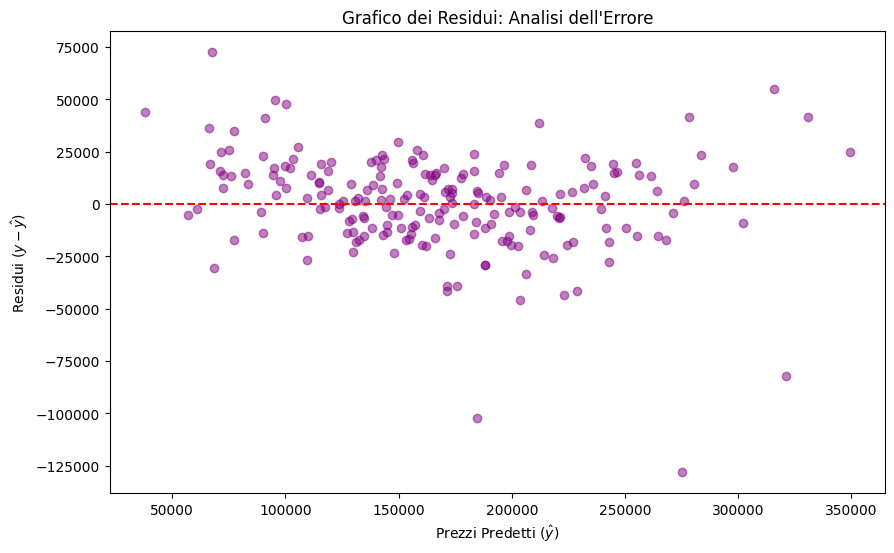

In [ ]:
from sklearn.linear_model import LinearRegression  # libreria Scikit Learn, tools per il machine learning
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Creazione e addestramento del modello
lr = LinearRegression()
lr.fit(X_train_std, y_train) # y train è il nostro target, in questo caso price

# 2. Generazione delle predizioni (QUESTO DEFINISCE y_pred)
y_pred = lr.predict(X_test_std)

# 3. Calcolo dei residui
residui = y_test - y_pred

# 4. Visualizzazione (usiamo r'' per evitare i SyntaxWarning)
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residui, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--')

plt.title('Grafico dei Residui: Analisi dell\'Errore')
plt.xlabel(r'Prezzi Predetti ($\hat{y}$)') # 'r' corregge il SyntaxWarning
plt.ylabel(r'Residui ($y - \hat{y}$)')
plt.show()

## Magari vado ad approfondire quei punti con quell'errore così enorme

## Per valutare quanto funziona bene il nostro modello vediamo degli indicatori

Per valutare un modello di regressione non basta "andare a occhio" guardando il grafico dei residui. Dobbiamo quantificare l'errore. In ambito accademico e professionale, le due metriche regine sono l'**RMSE** e l'****.

Ecco la spiegazione tecnica per distinguerle come un vero esperto.

---

## 1. RMSE (Root Mean Squared Error)

L'RMSE è il "termometro" del tuo modello: ti dice **quanto sono grandi, in media, i tuoi errori**.

### La Formula

$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

### Cosa ti dice davvero:

* **Unità di misura:** Il grande vantaggio dell'RMSE è che ha la **stessa unità di misura del target**. Se stai predicendo il prezzo in Euro, l'RMSE ti dirà: "Il modello sbaglia mediamente di  Euro".
* *Nota per il tuo caso:* Poiché abbiamo usato il **logaritmo** del prezzo, un RMSE di 0.12 indica un errore relativo di circa il 12%.


* **Severità:** Elevando gli errori al quadrato prima di farne la media, l'RMSE **punisce severamente gli errori grandi**. Se hai un solo errore enorme, l'RMSE schizzerà verso l'alto molto più di quanto farebbe altre metriche (come il MAE).

---

## 2.  (Coefficiente di Determinazione)

L'  è il "voto in pagella": ti dice **quanta informazione (varianza) hai catturato** rispetto a un modello banale.

### La Formula

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Dove  è la somma dei quadrati dei residui e  è la varianza totale dei dati.

### Cosa ti dice davvero:

* **Scala 0-1:** È un numero puro, non dipende dall'unità di misura.
* **1 :** Modello perfetto (spiega il 100% della varianza).
* **0.5 :** Il tuo modello è inutile (predice solo la media di tutti i prezzi).
* **0 :** Il tuo modello è peggiore di una semplice linea orizzontale (molto raro, indica errori gravi).


* **Interpretazione:** Se ottieni 0.85, significa che l'85% della variazione del prezzo delle case è spiegata dalle feature che hai scelto (mq, posizione, qualità), mentre il restante 15% è dovuto a fattori casuali o non inclusi nel dataset.

---

## Confronto Rapido

| Metrica | Domanda a cui risponde | Range ideale | Sensibile agli Outlier? |
| --- | --- | --- | --- |
| **RMSE** | "Di quanto sbaglio fisicamente in media?" | Più basso è, meglio è (vicino a 0) | **Sì**, molto |
| **R2** | "Quanto è bravo il modello rispetto alla media?" | Più alto è, meglio è (vicino a 1) | Moderatamente |

---

### Un segreto da "Expert"

Non fidarti mai solo dell'$R^2$  se aggiungi troppe variabili. L'$R^2$  tende ad aumentare sempre, anche se aggiungi colonne di numeri casuali! Per questo motivo, nei report avanzati si usa spesso l' ** Corretto (Adjusted )**, che penalizza il modello se aggiunge variabili inutili.


In [121]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R^2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2 Score: 0.8508
RMSE: 22880.6104


Quando hai molte feature (come le nostre 80+ nel dataset Ames), la regressione lineare standard (OLS) diventa "ingorda": cerca di adattarsi perfettamente a ogni punto del training set, finendo per imparare anche il **rumore**. Questo fenomeno si chiama **Overfitting**.

**Ridge** e **Lasso** sono tecniche di **Regolarizzazione** che servono a "dare una calmata" al modello, impedendo ai coefficienti  di diventare troppo grandi e assurdi.

---

### 1. Ridge Regression ( Regularization)

La Ridge aggiunge alla funzione di costo (il MSE) una penale basata sul **quadrato** dei coefficienti.

**La formula:**

$$J(\beta) = \text{MSE} + \alpha \sum_{j=1}^{p} \beta_j^2$$

* **Il trucco:** Il parametro  (lambda in alcuni testi) controlla quanto forte è la punizione. Se  è alto, il modello è costretto a tenere i coefficienti molto piccoli.
* **Perché usarla:** È fenomenale quando hai **multicollinearità** (variabili correlate). Invece di scegliere una variabile e scartare l'altra, la Ridge distribuisce il peso tra di loro, rendendo il modello più stabile.
* **Risultato:** I coefficienti si avvicinano allo zero, ma non diventano **mai esattamente zero**.

---

### 2. Lasso Regression ( Regularization)

Lasso sta per *Least Absolute Shrinkage and Selection Operator*. La penale qui si basa sul **valore assoluto** dei coefficienti.

**La formula:**

$$J(\beta) = \text{MSE} + \alpha \sum_{j=1}^{p} |\beta_j|$$

* **Il trucco:** A causa della geometria del valore assoluto (che ha una "punta" sullo zero), questa penale ha la capacità di forzare alcuni coefficienti a diventare **esattamente zero**.
* **Perché usarla:** È lo strumento perfetto per la **Feature Selection automatica**. Se hai 80 variabili ma solo 10 sono davvero importanti, Lasso "ucciderà" le altre 70 portandole a zero.
* **Risultato:** Ottieni un modello molto più semplice e interpretabile (*sparse model*).

---

### 3. La differenza visiva (L'intuizione geometrica)

Immagina di voler minimizzare l'errore restando dentro un "budget" di coefficienti:

* **Ridge** è come un cerchio: puoi muoverti ovunque, ma preferisci restare vicino al centro. Difficilmente toccherai gli assi (dove un coefficiente è zero).
* **Lasso** è come un diamante: ha gli angoli proprio sugli assi. È molto probabile che la soluzione ottima si trovi su un angolo, azzerando una variabile.

---

### Bias-Variance Tradeoff: Il compromesso dell'esperto

Perché dovremmo voler aggiungere un errore (la penale) di proposito?

1. **Aumentiamo il Bias (Distorsione):** Accettiamo che il modello non sia perfetto sul training set.
2. **Riduciamo la Variance (Varianza):** Otteniamo un modello che non impazzisce quando vede dati nuovi (test set).

In sintesi: **Rendiamo il modello un po' meno preciso sul passato per renderlo molto più affidabile sul futuro.**


## Ma confrontiamo queste ottimizzazioni

In [122]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Definiamo i modelli
# Alpha = 0.1 è una regolarizzazione moderata per mostrare l'effetto
models = {
    "Senza Regolarizzazione (OLS)": LinearRegression(),
    "L1 (Lasso)": Lasso(alpha=0.1),
    "L2 (Ridge)": Ridge(alpha=0.1),
    "L1 + L2 (ElasticNet)": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []

for name, model in models.items():
    # Addestramento
    model.fit(X_train_std, y_train)
    
    # Predizione
    y_pred = model.predict(X_test_std)
    
    # Calcolo metriche
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Modello": name,
        "R2 Score": round(r2, 4),
        "RMSE": round(rmse, 4)
    })

# Visualizzazione dei risultati
df_results = pd.DataFrame(results)
display(df_results)

c:\Users\mbagn\anaconda3\envs\pytorch\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.260e+10, tolerance: 3.386e+08
  model = cd_fast.enet_coordinate_descent(


,Modello,R2 Score,RMSE
0,Senza Regolarizzazione (OLS),0.851,22880.610
1,L1 (Lasso),0.849,22986.562
2,L2 (Ridge),0.851,22861.579
3,L1 + L2 (ElasticNet),0.870,21326.481



## 1. Il Concetto di Classificazione

In Machine Learning, la **Classificazione** è il processo di predizione di una **etichetta discreta** (o categoria). A differenza della regressione, dove cerchiamo di stimare un valore su una scala infinita, qui vogliamo assegnare un'osservazione a una "scatola" specifica.

* **Classificazione Binaria:** Esistono solo due classi (Sì/No, 0/1, Lusso/Standard).
* **Classificazione Multiclasse:** Esistono più di due categorie mutuamente esclusive (es. classificare una casa come "Villetta", "Appartamento" o "Condominio").

Il cuore della classificazione è trovare un **Decision Boundary** (confine di decisione): una linea, un piano o una superficie curva che separi al meglio le diverse classi nello spazio delle caratteristiche (feature).

---

## 2. La Logistic Regression: L'Anello di Congiunzione

La **Logistic Regression** è l'algoritmo fondamentale per la classificazione binaria. È affascinante perché, tecnicamente, inizia come una regressione lineare ma finisce come un classificatore probabilistico.

### A. La componente lineare

Il punto di partenza è identico alla regressione lineare. Calcoliamo una combinazione pesata delle nostre variabili (x):

$$z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots + \beta_nx_n$$

In questo stadio,  può essere qualunque numero (da  a ). Tuttavia, noi abbiamo bisogno di una probabilità, che per definizione deve stare tra **0 e 1**.

### B. La Funzione Sigmoide (o Logistica)

Per "schiacciare" il valore di  nell'intervallo 0,1, applichiamo la **funzione sigmoide**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Questa curva a "S" ha proprietà matematiche bellissime:

1. Se  è molto grande e positivo,  tende a **1**.
2. Se  è molto grande e negativo,  tende a **0**.
3. Se ,  (il punto di massima incertezza).

---

## 3. Interpretazione dei "Log-Odds"

Perché si chiama "Logistica"? Perché l'equazione può essere riscritta in termini di **Odds** (probabilità a favore rispetto a probabilità contro). Se p è la probabilità che una casa sia di lusso:

$$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1x_1 + \dots$$

Questa espressione  $\ln\left(\frac{p}{1-p}\right)$  è chiamata **Logit**.
Questo significa che i coefficienti  della Logistic Regression non indicano di quanto aumenta il prezzo, ma di quanto aumenta il **logaritmo del rapporto di probabilità** per ogni unità in più di una feature.

---

## 4. Come impara il modello: La Log-Loss

Nella regressione lineare cercavamo di minimizzare la somma dei quadrati degli errori (MSE). Nella Logistic Regression, l'MSE non funziona bene perché la sigmoide renderebbe la funzione di costo "non convessa" (piena di dossi e valli dove l'algoritmo potrebbe incastrarsi).

Usiamo invece la **Log-Loss** (chiamata anche *Binary Cross-Entropy*):

$$J(\beta) = -\frac{1}{n} \sum_{i=1}^{n} [y_i \ln(\hat{y}_i) + (1-y_i) \ln(1-\hat{y}_i)]$$

**La logica dietro questa formula è geniale:**

* Se la classe reale è  () e il modello predice una probabilità vicina a , l'errore è quasi zero.
* Se la classe reale è  ma il modello predice una probabilità vicina a , la funzione  tende a infinito, punendo il modello con un errore enorme.

---

## 5. Il Confine di Decisione (Decision Threshold)

Una volta ottenuta la probabilità (es. 0.72), come decidiamo se la casa è effettivamente di lusso?
Applichiamo una **soglia** (threshold), solitamente fissata a **0.5**:

* Se $p \ge 0.5 \rightarrow$ Classe 1 (Lusso)
* Se $p < 0.5 \rightarrow$ Classe 0 (Standard)

Un esperto sa che questa soglia può essere spostata. Se stessimo classificando tumori, vorremmo essere molto cauti e potremmo abbassare la soglia a 0.2 per non rischiare di ignorare un caso sospetto, accettando però più "falsi allarmi".



<>:37: SyntaxWarning: invalid escape sequence '\h'
<>:37: SyntaxWarning: invalid escape sequence '\h'
C:\Users\mbagn\AppData\Local\Temp\ipykernel_27940\2474202506.py:37: SyntaxWarning: invalid escape sequence '\h'
  ax[1].set_xlabel('Probabilità Predetta dal Modello ($\hat{y}$)', fontsize=12)


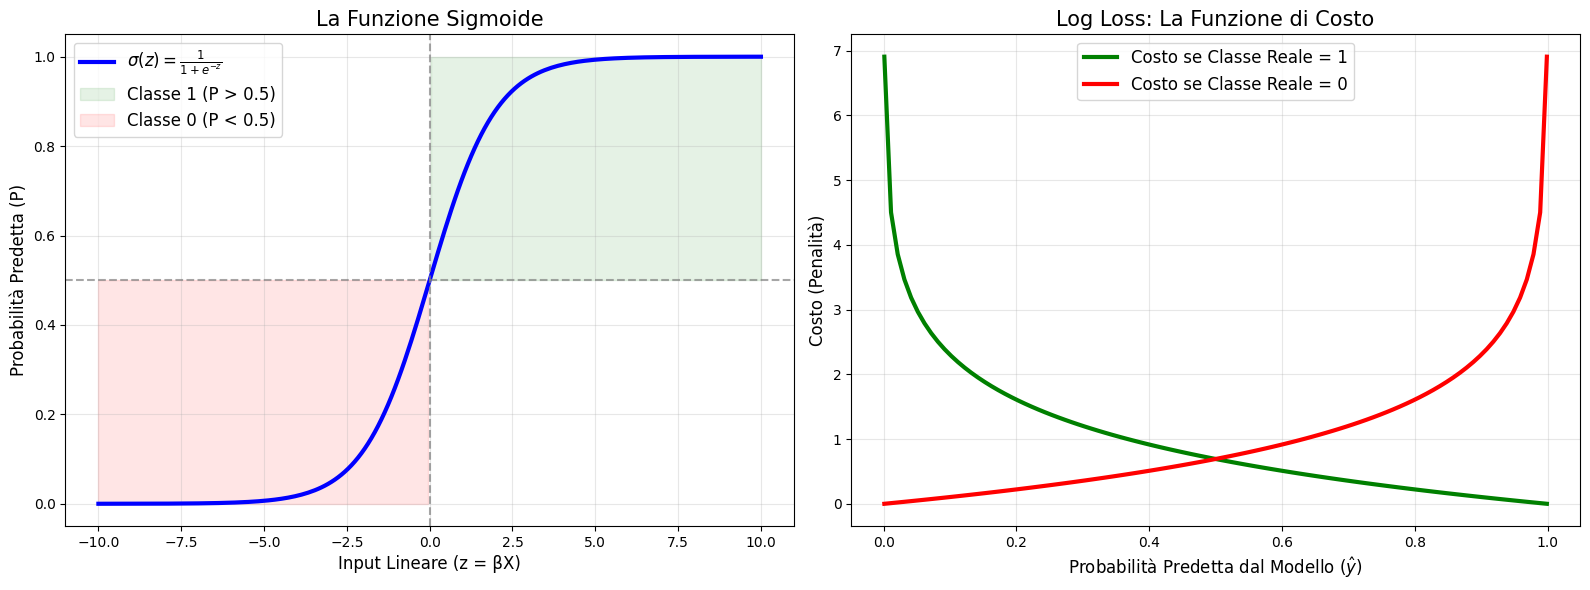

In [123]:
import numpy as np
import matplotlib.pyplot as plt

# 1. FUNZIONE SIGMOIDE
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Generiamo un range di valori per l'input lineare z (da -10 a 10)
z = np.linspace(-10, 10, 200)
p = sigmoid(z)

# 2. LOG LOSS (BINARY CROSS-ENTROPY)
# Generiamo un range di probabilità predette (da 0.01 a 0.99 per evitare log(0))
y_hat = np.linspace(0.001, 0.999, 100)
loss_y1 = -np.log(y_hat)       # Errore se la classe reale è 1
loss_y0 = -np.log(1 - y_hat)   # Errore se la classe reale è 0

# --- VISUALIZZAZIONE ---
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# GRAFICO 1: SIGMOIDE
ax[0].plot(z, p, color='blue', lw=3, label=r'$\sigma(z) = \frac{1}{1 + e^{-z}}$')
ax[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.7)
ax[0].axvline(x=0, color='gray', linestyle='--', alpha=0.7)
ax[0].fill_between(z, 0.5, 1, where=(z >= 0), color='green', alpha=0.1, label='Classe 1 (P > 0.5)')
ax[0].fill_between(z, 0, 0.5, where=(z < 0), color='red', alpha=0.1, label='Classe 0 (P < 0.5)')
ax[0].set_title('La Funzione Sigmoide', fontsize=15)
ax[0].set_xlabel('Input Lineare (z = βX)', fontsize=12)
ax[0].set_ylabel('Probabilità Predetta (P)', fontsize=12)
ax[0].legend(fontsize=12)
ax[0].grid(True, alpha=0.3)

# GRAFICO 2: LOG LOSS
ax[1].plot(y_hat, loss_y1, color='green', lw=3, label='Costo se Classe Reale = 1')
ax[1].plot(y_hat, loss_y0, color='red', lw=3, label='Costo se Classe Reale = 0')
ax[1].set_title('Log Loss: La Funzione di Costo', fontsize=15)
ax[1].set_xlabel('Probabilità Predetta dal Modello ($\hat{y}$)', fontsize=12)
ax[1].set_ylabel('Costo (Penalità)', fontsize=12)
ax[1].legend(fontsize=12)
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

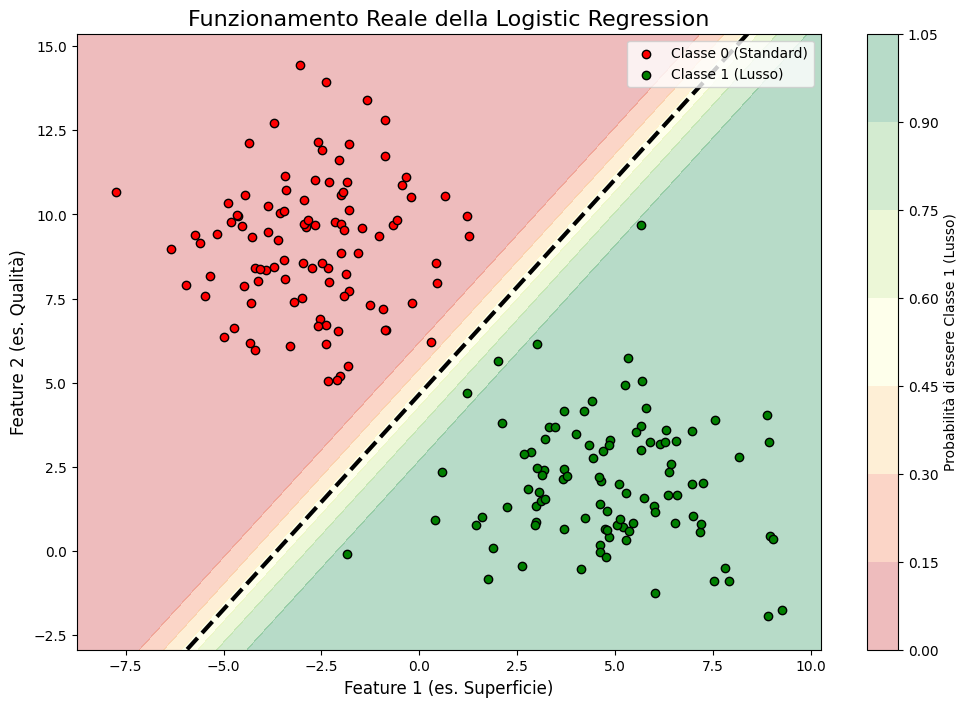

Coefficienti (Pesi W): [[ 1.43231585 -1.12093278]]
Intercetta (Bias b): [5.21999523]


In [124]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs

# 1. GENERAZIONE DATI SINTETICI (2 Feature per poterle mappare su assi X e Y)
# Creiamo due "nuvole" di punti ben distinte ma con un po' di sovrapposizione
X_syn, y_syn = make_blobs(n_samples=200, centers=2, n_features=2, cluster_std=2.0, random_state=42)

# 2. ADDESTRAMENTO
clf = LogisticRegression()
clf.fit(X_syn, y_syn)

# 3. CREAZIONE DELLA GRIGLIA PER IL BACKGROUND (PROBABILITÀ)
# Vogliamo colorare lo sfondo in base alla probabilità predetta
x_min, x_max = X_syn[:, 0].min() - 1, X_syn[:, 0].max() + 1
y_min, y_max = X_syn[:, 1].min() - 1, X_syn[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Prediciamo la probabilità per ogni punto della griglia
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

# 4. VISUALIZZAZIONE
plt.figure(figsize=(12, 8))

# Disegniamo i contorni di probabilità (lo sfondo sfumato)
contour = plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
plt.colorbar(contour, label='Probabilità di essere Classe 1 (Lusso)')

# Disegniamo il Decision Boundary (dove P = 0.5)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=3, linestyles='--')

# Disegniamo i punti reali
plt.scatter(X_syn[y_syn==0, 0], X_syn[y_syn==0, 1], color='red', edgecolors='k', label='Classe 0 (Standard)')
plt.scatter(X_syn[y_syn==1, 0], X_syn[y_syn==1, 1], color='green', edgecolors='k', label='Classe 1 (Lusso)')

plt.title('Funzionamento Reale della Logistic Regression', fontsize=16)
plt.xlabel('Feature 1 (es. Superficie)', fontsize=12)
plt.ylabel('Feature 2 (es. Qualità)', fontsize=12)
plt.legend()
plt.show()

# 5. ESTRAZIONE DEI PARAMETRI REALI
print(f"Coefficienti (Pesi W): {clf.coef_}")
print(f"Intercetta (Bias b): {clf.intercept_}")

Passiamo a uno dei "pesi massimi" del Machine Learning: le **Support Vector Machines (SVM)**. Se la Logistic Regression cerca di stimare probabilità, la SVM ragiona come un geometra: cerca la **separazione fisica ottimale** tra le classi.

---

## 1. Il Concetto di Margine Massimo

Immagina di dover tracciare una linea per separare due gruppi di punti. Esistono infinite linee possibili. Quale scegliamo?

La SVM sceglie la linea (o **iperpiano**) che lascia lo spazio più ampio possibile tra sé e i punti più vicini di ogni classe. Questo spazio è chiamato **Margine**.

* **L'obiettivo:** Massimizzare questo margine. Più la "terra di nessuno" tra le classi è larga, più il modello sarà robusto quando vedrà nuovi dati.

---

## 2. I Support Vectors (I Protagonisti)

Perché si chiama così? In un dataset di 1000 punti, la SVM non si cura di 998 di essi. Si concentra solo sui pochi punti che si trovano proprio sul bordo del margine.

* Questi punti critici sono i **Support Vectors** (Vettori di Supporto).
* Se sposti un punto lontano dal confine, la linea non cambia. Se sposti un Support Vector, l'intero confine deve ruotare o spostarsi. Sono loro che "reggono" la struttura del modello.

---

## 3. Il Trucco del Kernel (Kernel Trick)

Cosa succede se i dati non sono separabili da una linea retta? Ad esempio, se i punti rossi sono al centro di un cerchio e quelli verdi tutto intorno?

La SVM usa il **Kernel Trick**: proietta i dati in una dimensione superiore (es. da 2D a 3D). In questa nuova dimensione, i dati che prima erano mescolati diventano magicamente separabili da un piano piatto.

* **Linear Kernel:** Per dati già ben separabili linearmente.
* **RBF (Radial Basis Function):** Il più usato. Crea confini circolari o complessi, mappando i dati in uno spazio a infinite dimensioni.
* **Polynomial Kernel:** Utile per relazioni di tipo curvo.

---

## 4. Parametro C: Il compromesso tra "Pulizia" e "Margine"

Nella realtà, i dati sono sporchi e qualche punto può finire nel "territorio nemico". Qui entra in gioco il parametro di regolarizzazione **C**:

* **C piccolo (Soft Margin):** Il modello è tollerante. Accetta qualche errore di classificazione pur di avere un margine molto largo. Evita l'overfitting.
* **C grande (Hard Margin):** Il modello è severo. Cerca di classificare correttamente ogni singolo punto, anche a costo di creare un margine strettissimo e una linea tutta storta. Rischia l'overfitting.

---

## 5. La Matematica in sintesi

Senza entrare in calcoli complessi, la SVM risolve un problema di ottimizzazione quadratica. L'iperpiano è definito da:

Il margine che vogliamo massimizzare ha ampiezza . Minimizzare il vettore dei pesi  equivale a massimizzare lo spazio tra le classi.

$$w^T x + b = 0$$

---

### Perché la SVM è perfetta per il nostro progetto?

1. **Versatilità:** Grazie ai Kernel, può imparare qualsiasi forma di confine.
2. **Efficienza:** Funziona bene anche se abbiamo molte feature e relativamente pochi dati (come nel caso delle 80 colonne di Ames).
3. **Memoria:** Usa solo i Support Vectors, quindi è molto efficiente in fase di predizione.

> **Nota importante:** La SVM è estremamente sensibile alla scala dei dati (perché calcola distanze geometriche). Ecco perché lo **StandardScaler** che abbiamo applicato prima è stato il passaggio più importante di tutto il lavoro!



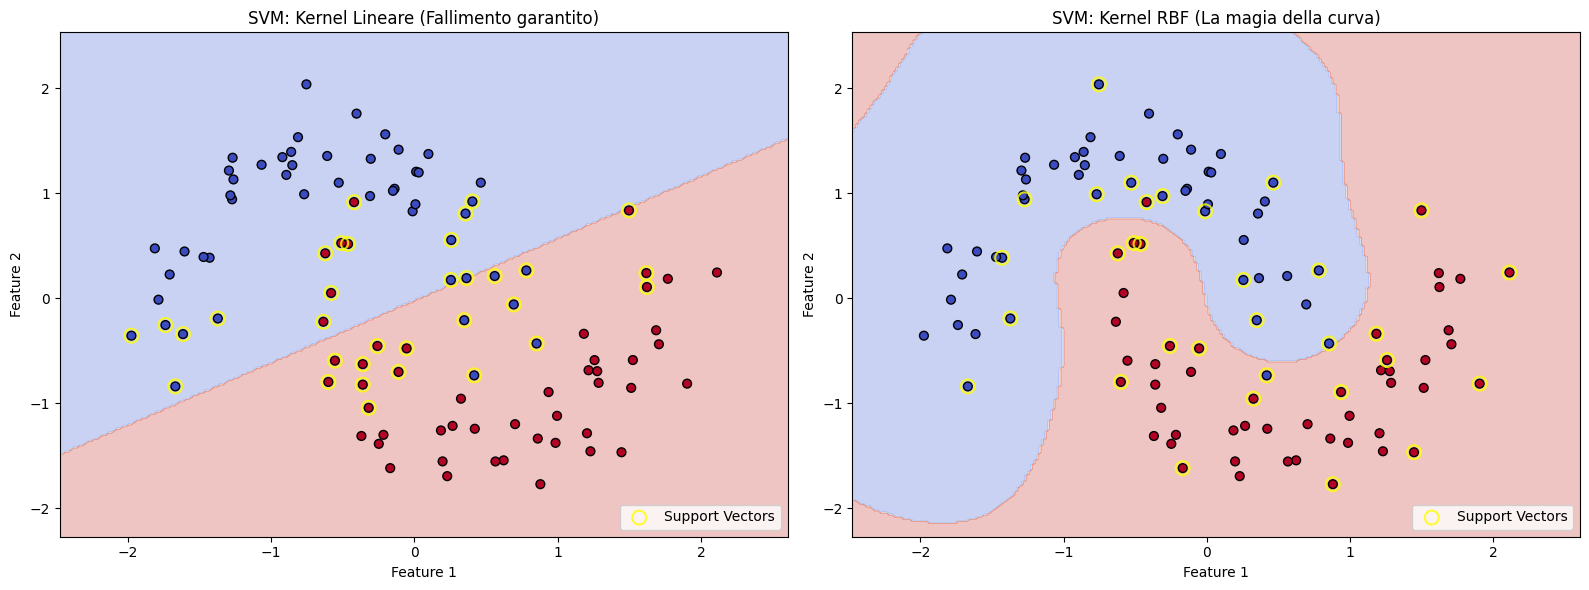

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Creazione del dataset a "mezzaluna" (Moons)
# n_samples: numero di punti, noise: quanto sono "sporchi" i dati
X, y = datasets.make_moons(n_samples=100, noise=0.15, random_state=42)

# Nota: SVM beneficia enormemente dalla scalatura dei dati
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 2. Creazione dei modelli
# Linear: proverà disperatamente a tracciare una retta
# RBF: userà il "kernel trick" per mappare i dati in una dimensione superiore e curvare
models = (SVC(kernel='linear', C=1.0),
          SVC(kernel='rbf', gamma=1.5, C=1.0))
models = [clf.fit(X, y) for clf in models]

# 3. Visualizzazione
titles = ('SVM: Kernel Lineare (Fallimento garantito)', 
          'SVM: Kernel RBF (La magia della curva)')
fig, sub = plt.subplots(1, 2, figsize=(16, 6))

for clf, title, ax in zip(models, titles, sub):
    # Creazione della griglia per il background colorato
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Confini di decisione
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    
    # Punti del dataset
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=40)
    
    # Support Vectors (quelli che "reggono" il confine)
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
                linewidth=1.5, facecolors='none', edgecolors='yellow', 
                label='Support Vectors', alpha=0.8)
    
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

## Ma come valuto la precisione del mio modello?

La **Confusion Matrix** (Matrice di Confusione) è lo strumento definitivo per capire non solo *se* il tuo modello sta sbagliando, ma soprattutto **come** sta sbagliando.

Mentre l'accuratezza ti dice genericamente "hai indovinato l'80% delle volte", la matrice di confusione ti dice: "hai scambiato 10 ville di lusso per case popolari e 5 case popolari per ville di lusso".

---

### 1. Com'è fatta la Matrice?

È una tabella quadrata che confronta le **Classi Reali** (le righe) con le **Classi Predette** (le colonne). In un problema binario (0 o 1), si presenta così:

|  | Predetto: 0 (Standard) | Predetto: 1 (Lusso) |
| --- | --- | --- |
| **Reale: 0 (Standard)** | **True Negative (TN)** | **False Positive (FP)** |
| **Reale: 1 (Lusso)** | **False Negative (FN)** | **True Positive (TP)** |

#### I 4 Quadranti della Verità:

1. **True Positive (TP):** La casa è di lusso e il modello l'ha azzeccata. (Successo)
2. **True Negative (TN):** La casa è standard e il modello l'ha azzeccata. (Successo)
3. **False Positive (FP) - Errore di Tipo I:** Il modello dice "Lusso", ma la casa è "Standard". È un **falso allarme**.
4. **False Negative (FN) - Errore di Tipo II:** Il modello dice "Standard", ma la casa è "Lusso". È un'**occasione persa**.

---

### 2. Le Metriche derivate (Oltre l'Accuratezza)

Dalla matrice estraiamo i "voti" del modello. Ognuno serve a uno scopo diverso.

#### **Accuracy (Accuratezza)**

È la percentuale di previsioni corrette sul totale.

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

* **Quando usarla:** Quando le classi sono bilanciate (50% lusso, 50% standard). Se il 99% delle case fosse standard, un modello che dice sempre "standard" avrebbe il 99% di accuratezza ma sarebbe inutile.

#### **Precision (Precisione)**

Risponde alla domanda: *"Quando il modello dice 'Lusso', quante volte ha ragione?"*

$$Precision = \frac{TP}{TP + FP}$$

* **Obiettivo:** Minimizzare i Falsi Positivi. Utile se il marketing per le case di lusso è costosissimo e non vuoi sprecarlo con chi ha una casa normale.

#### **Recall (Sensibilità)**

Risponde alla domanda: *"Su tutte le case di lusso esistenti, quante ne ho trovate?"*

$$Recall = \frac{TP}{TP + FN}$$

* **Obiettivo:** Minimizzare i Falsi Negativi. Utile se sei un investitore che non vuole lasciarsi sfuggire nessuna occasione di lusso sul mercato.

#### **F1-Score**

È la media armonica tra Precision e Recall. Ti dà un valore unico che bilancia entrambi.

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

---

### 3. Esempio Pratico: L'importanza del Contesto

Immagina di avere questi due scenari per il tuo modello di classificazione case:

* **Scenario A (Alta Precisione):** Il modello è molto "timido". Dice che è lusso solo quando è sicurissimo. Avrai pochi falsi allarmi, ma ti perderai molte case belle (Recall bassa).
* **Scenario B (Alta Recall):** Il modello è molto "entusiasta". Dice che quasi tutto è lusso. Troverai tutte le ville, ma dentro ci finiranno anche molti appartamenti normali (Precisione bassa).

**Un bravo data scientist sceglie il modello in base a cosa costa di più: fare un falso allarme o perdere un'occasione?**



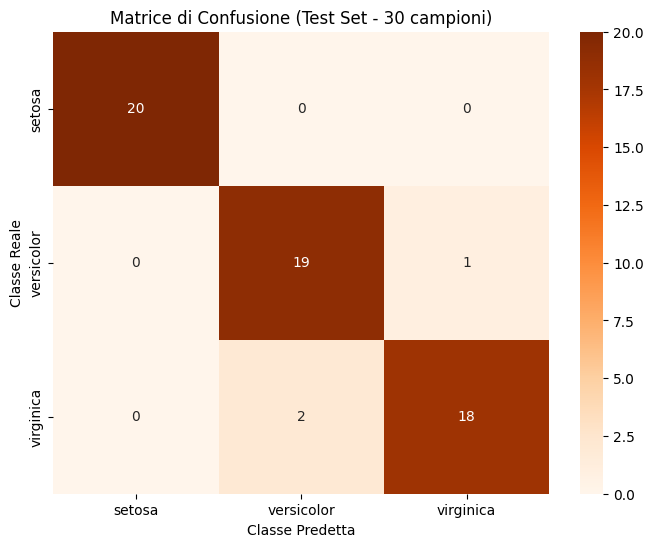


--- Report di Classificazione Iris (Test Set) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        20
  versicolor       0.90      0.95      0.93        20
   virginica       0.95      0.90      0.92        20

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



In [131]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# 1. Caricamento dati
iris = datasets.load_iris()
X, y = iris.data, iris.target
target_names = iris.target_names

# 2. Split (stratify è fondamentale per mantenere le proporzioni delle classi)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# 3. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Training
svm_iris = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_iris.fit(X_train_scaled, y_train)

# 5. Predizione (SUL TEST SET - 30 campioni)
y_test_pred = svm_iris.predict(X_test_scaled)

# 6. Visualizzazione Confusion Matrix (Test Set)
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('Matrice di Confusione (Test Set - 30 campioni)')
plt.xlabel('Classe Predetta')
plt.ylabel('Classe Reale')
plt.show()

# 7. Report delle Metriche (Ora le dimensioni coincidono: 30 vs 30)
print("\n--- Report di Classificazione Iris (Test Set) ---")
print(classification_report(y_test, y_test_pred, target_names=target_names))

Gli **Alberi di Decisione (Decision Trees)** rappresentano un cambio di paradigma totale. Se finora abbiamo usato la geometria (SVM) o l'algebra (Regressione), qui entriamo nel regno della **logica pura** e della **teoria dell'informazione**.

Immagina un albero di decisione come un sofisticato gioco di "Indovina Chi?": il modello pone una serie di domande binarie (Sì/No) per restringere il campo fino ad arrivare a una conclusione.

---

## 1. La Logica: Partizionamento Ricorsivo

L'albero divide lo spazio dei dati in rettangoli sempre più piccoli. Ogni "nodo" dell'albero rappresenta una domanda su una feature (es. "La superficie è superiore a 150mq?").

* Se la risposta è **Sì**, seguiamo il ramo destro.
* Se la risposta è **No**, seguiamo il ramo sinistro.

Questo processo continua finché non arriviamo a una "foglia" (**Leaf Node**), che contiene la previsione finale.

---

## 2. La Matematica: Come sceglie la "Domanda" migliore?

Un albero non sceglie le domande a caso. Cerca il punto di divisione (*split*) che rende i gruppi risultanti il più "puri" possibile. Per misurare questa purezza, usiamo due metriche principali:

### A. Entropia e Information Gain (ID3/C4.5)

L'Entropia misura il disordine o l'incertezza in un gruppo di dati.

$$H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$

Dove  è la proporzione di campioni della classe .

* Se un nodo ha solo fiori *Setosa*, l'entropia è **0** (ordine massimo).
* Se ha il 50% *Setosa* e 50% *Versicolor*, l'entropia è **1** (caos massimo).

L'albero sceglie lo split che garantisce il massimo **Information Gain** (riduzione dell'entropia).

### B. Indice di Gini (Algoritmo CART)

È lo standard usato da Scikit-Learn. Misura la probabilità di classificare erroneamente un elemento scelto a caso.

$$Gini = 1 - \sum_{i=1}^{c} p_i^2$$

Proprio come l'entropia, l'obiettivo è minimizzare questo valore fino a raggiungere lo zero.

---

## 3. I Vantaggi: Perché sono così popolari?

* **Interpretabilità (White Box):** Puoi stampare l'albero e leggerlo come un diagramma di flusso. È facile spiegare a un cliente perché la sua casa è stata valutata in un certo modo.
* **Zero Pre-processing:** Non hanno bisogno di scaling (StandardScaler). Per un albero, non importa se la superficie è 100 o 1.000.000; la soglia di taglio sarà comunque relativa.
* **Relazioni Non-Lineari:** Catturano naturalmente interazioni complesse (es. "Se la casa è vecchia MA è stata ristrutturata, allora il prezzo sale") che i modelli lineari faticano a vedere.
* **Robustezza agli Outlier:** Un valore estremo influenza solo la foglia in cui cade, non l'intera struttura (a differenza della regressione).

---

## 4. Il "Tallone d'Achille": L'Overfitting

Il problema principale degli alberi è che sono **troppo bravi**. Se li lasciamo fare, creeranno un ramo per ogni singolo record del dataset, imparando il rumore a memoria.
Per evitarlo, usiamo il **Pruning** (potatura) o limitiamo la profondità massima (`max_depth`).

---

## Prossimo Step: Visualizziamo l'Albero!

Visto che stiamo usando il dataset **Iris**, l'albero è perfetto perché possiamo letteralmente "vederlo in faccia".

**Ti va di generare l'albero di decisione per Iris e stamparne il grafico per vedere quali soglie di Petal/Sepal ha scelto il modello?** *È molto gratificante vedere la logica matematica trasformata in un disegno leggibile.*

**Procediamo?**

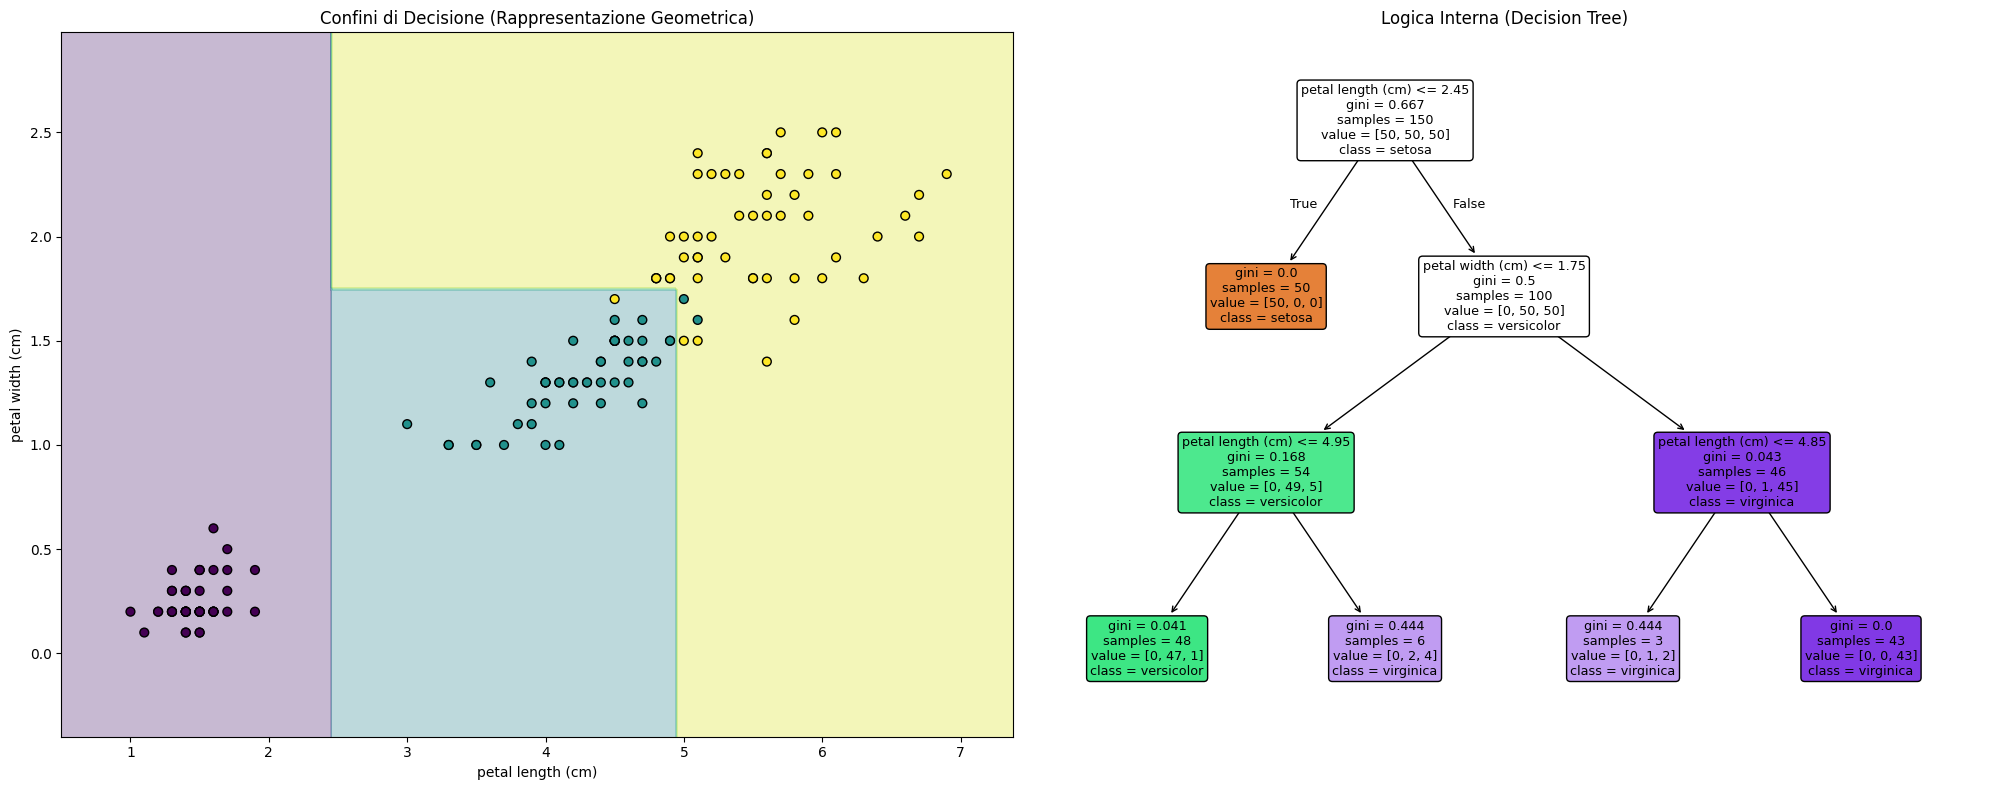

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Caricamento dati - Usiamo solo Petal Length e Petal Width per la visualizzazione
iris = datasets.load_iris()
X = iris.data[:, 2:4] # Feature 2 e 3 (Petali)
y = iris.target

# 2. Addestramento del modello
# max_depth=3 è perfetto per vedere bene i "tagli" senza complicare troppo
tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X, y)

# 3. Creazione del grafico con due sotto-grafici (Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- SOTTO-GRAFICO 1: Confini di Decisione ---
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax1.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = ax1.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=40, cmap='viridis')
ax1.set_title("Confini di Decisione (Rappresentazione Geometrica)")
ax1.set_xlabel(iris.feature_names[2])
ax1.set_ylabel(iris.feature_names[3])

# --- SOTTO-GRAFICO 2: Struttura dell'Albero ---
plot_tree(tree_clf, 
          feature_names=[iris.feature_names[2], iris.feature_names[3]],  
          class_names=iris.target_names, 
          filled=True, rounded=True, ax=ax2)
ax2.set_title("Logica Interna (Decision Tree)")

plt.tight_layout()
plt.show()

Se l'Albero di Decisione è un singolo esperto che può essere testardo e sbagliare (overfitting), la **Random Forest** è un'intera commissione di esperti che vota per prendere la decisione migliore.

È uno dei modelli più potenti e versatili del Machine Learning, basato sul principio della **Saggezza della Folla** (*Wisdom of the Crowd*). Tecnicamente, appartiene alla famiglia dell'**Ensemble Learning**, specificamente alla categoria del **Bagging**.

---

### 1. I Tre Pilastri della Random Forest

Perché una foresta sia "buona", gli alberi che la compongono devono essere due cose: **esperti** e **diversi** tra loro. Se tutti gli alberi fossero uguali, avremmo lo stesso errore moltiplicato per cento. La Random Forest ottiene questa diversità tramite due meccanismi di casualità:

#### A. Bagging (Bootstrap Aggregating)

Invece di dare a ogni albero tutto il dataset, ogni albero riceve un campione casuale estratto con reinserimento (*Bootstrap sample*).

* Alcune righe del dataset appariranno più volte per un albero, altre non appariranno affatto (dati *Out-of-Bag*).
* Questo assicura che ogni albero veda una "sfumatura" diversa della realtà.

#### B. Feature Randomness (Random Subspace)

Questa è la vera magia. Quando un albero deve decidere come fare uno split (una domanda), non può guardare tutte le feature disponibili. Ne può scegliere solo un **sottogruppo casuale** (solitamente  dove  è il numero totale di variabili).

* **Perché?** Se ci fosse una variabile dominante (es. la superficie della casa), ogni albero la userebbe come prima domanda. Avremmo 100 alberi quasi identici. Limitando le feature, costringiamo alcuni alberi a diventare "esperti" di variabili secondarie (es. l'anno di costruzione o il numero di camini).

#### C. Aggregazione (Voting/Averaging)

* **Classificazione:** Ogni albero emette un voto (es. "Lusso"). La classe con più voti vince.
* **Regressione:** Ogni albero predice un numero. La Random Forest calcola la media di tutte le predizioni.

---

### 2. La Matematica: Ridurre la Varianza

La forza della Random Forest sta nella riduzione della **Varianza** senza aumentare significativamente il **Bias** (distorsione).

Se  $X_1, X_2, \dots, X_n$ sono le predizioni di  alberi indipendenti, ognuno con varianza , la varianza della loro media è:

$$\text{Var}(\bar{X}) = \frac{\sigma^2}{n}$$

Nella realtà gli alberi non sono perfettamente indipendenti (usano lo stesso dataset), quindi la formula reale include la correlazione :

$$\text{Var}(\text{Forest}) = \rho \sigma^2 + \frac{1-\rho}{n} \sigma^2$$

Aumentando il numero di alberi (), il secondo termine tende a zero. La foresta sarà sempre più stabile di un singolo albero.

---

### 3. Vantaggi e Svantaggi

| Vantaggi | Svantaggi |
| --- | --- |
| **Robustissima all'Overfitting:** Grazie alla media dei voti, gli errori dei singoli alberi si annullano. | **Meno Interpretabile:** È una "Black Box". Non puoi più leggere un diagramma di flusso come per l'albero singolo. |
| **Feature Importance:** Ti dice esattamente quali variabili pesano di più nel complesso. | **Lenta in Predizione:** Deve far girare 100+ alberi per darti una risposta. |
| **Gestisce dati mancanti:** Funziona bene anche se il dataset non è perfetto. | **Non estrapola:** Non può predire valori fuori dal range visto nel training (problema della regressione). |

---

### 4. Il concetto di "Out-of-Bag" (OOB) Score

Poiché ogni albero non vede circa il 36% dei dati durante l'addestramento, possiamo usare quei dati "nascosti" per testare l'albero immediatamente. La media di questi test è lo **OOB Score**, una sorta di cross-validation interna gratuita che ci dice quanto è affidabile la foresta senza bisogno di un test set esterno.


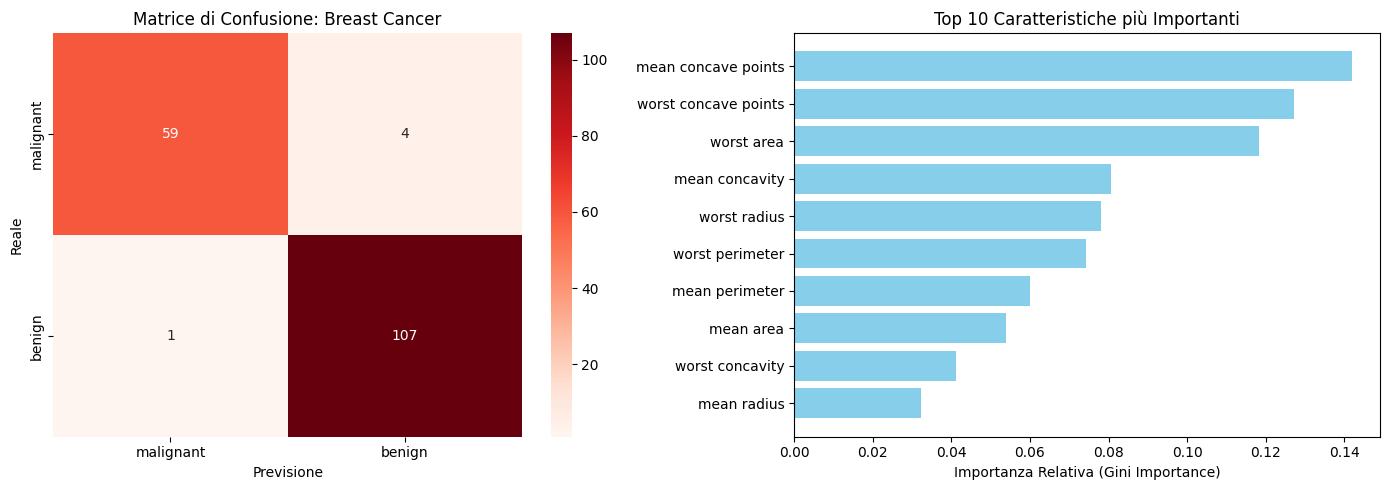

              precision    recall  f1-score   support

   malignant       0.98      0.94      0.96        63
      benign       0.96      0.99      0.98       108

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

# 1. Caricamento dati
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Addestramento Random Forest
# Usiamo 100 alberi (n_estimators)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 4. Predizione
y_pred = rf_clf.predict(X_test)

# --- GRAFICO 1: MATRICE DI CONFUSIONE ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Matrice di Confusione: Breast Cancer')
plt.xlabel('Previsione')
plt.ylabel('Reale')

# --- GRAFICO 2: FEATURE IMPORTANCE ---
plt.subplot(1, 2, 2)
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[-10:] # Prendiamo le 10 più importanti

plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [data.feature_names[i] for i in indices])
plt.title('Top 10 Caratteristiche più Importanti')
plt.xlabel('Importanza Relativa (Gini Importance)')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=data.target_names))

Se la **Random Forest** è una democrazia (tutti votano contemporaneamente e si fa la media), il **Boosting** è un **regime di eccellenza sequenziale**.

È una tecnica di *Ensemble Learning* che non costruisce alberi indipendenti, ma li mette in fila: ogni nuovo albero viene addestrato con l'unico obiettivo di **correggere gli errori** commessi dai suoi predecessori.

---

### 1. La Filosofia: Trasformare "Deboli" in "Forti"

Il Boosting parte dal presupposto che sia meglio avere 100 "studenti" che imparano dai propri sbagli piuttosto che 100 "esperti" che non si parlano tra loro.

* **Weak Learners:** In genere si usano alberi molto semplici (spesso chiamati *Decision Stumps*, ovvero alberi con un solo livello).
* **Apprendimento Sequenziale:** Il primo albero fa una previsione. Alcuni punti verranno classificati male. Il secondo albero si focalizzerà quasi esclusivamente su quei punti difficili.
* **Risultato Finale:** È una combinazione pesata di tutti gli alberi. Quelli che hanno dimostrato di essere più accurati hanno un "voto" più pesante.

---

### 2. Come funziona matematicamente? (L'intuizione dei Residui)

Mentre AdaBoost (uno dei primi algoritmi) aumentava il "peso" degli esempi sbagliati, il **Gradient Boosting** (la base di XGBoost) lavora sui **residui**.

Immagina di voler predire il prezzo di una casa ():

1. **Albero 1:** Predice . L'errore (residuo) è .
2. **Albero 2:** Non prova a predire , ma prova a predire l'errore: ****. Se ne predice , l'errore totale scende a .
3. **Albero 3:** Prova a predire il nuovo errore: ****.

Alla fine, la previsione è la somma di tutti gli alberi:

$$\hat{y} = f_1(x) + f_2(x) + f_3(x) + \dots$$

---

### 3. Vantaggi del Boosting

| Caratteristica | Perché è un vantaggio |
| --- | --- |
| **Precisione Superiore** | Spesso raggiunge performance che Random Forest o SVM non possono toccare. |
| **Gestione Bias-Varianza** | È imbattibile nel ridurre il **Bias** (l'errore sistematico), rendendo il modello estremamente preciso. |
| **Flessibilità** | Puoi ottimizzare qualsiasi funzione di costo (non solo l'errore quadratico). |
| **Feature Importance** | Come la Random Forest, fornisce una classifica chiara di cosa conta davvero nei dati. |

---

### 4. I "Big Three" del Boosting moderno

Oggi non si scrive quasi mai il codice per il Gradient Boosting da zero. Si usano librerie ottimizzate che sono diventate lo standard dell'industria:

1. **XGBoost (Extreme Gradient Boosting):** Il re di Kaggle. Introduce la regolarizzazione all'interno degli alberi per evitare l'overfitting.
2. **LightGBM (Microsoft):** Velocissimo, ottimo per dataset enormi. "Cresce" gli alberi in modo diverso (leaf-wise).
3. **CatBoost (Yandex):** Gestisce le variabili categoriche (come "Quartiere" o "Tipo di Tetto") in modo magico, senza bisogno di One-Hot Encoding manuale.

---

### Lo svantaggio: Il rischio "Overfitting"

A differenza della Random Forest, il Boosting è **molto sensibile al rumore**. Se gli dai troppi alberi o troppa libertà, inizierà a "inseguire" anche gli errori casuali (outlier), creando un modello che è perfetto sul training ma disastroso sul test. Per questo usiamo il **Learning Rate** (che rallenta l'apprendimento per renderlo più stabile).


XGBoost non è solo un algoritmo, è un vero e proprio "pannello di controllo" con decine di manopole. Saperle girare nel modo giusto trasforma un modello mediocre in un modello da primo posto su Kaggle.

Ecco la guida definitiva alle ottimizzazioni pratiche, divisa per "obiettivi di volo".

---

## 1. I Parametri di Controllo della Struttura (Pruning e Complessità)

Questi parametri decidono quanto "ramificato" e complesso debba essere ogni singolo albero.

* **`max_depth` (Profondità Massima):**
* **Cos'è:** Il numero massimo di livelli dell'albero.
* **Scopo:** Controlla l'interazione tra le variabili. Più è profondo, più il modello impara relazioni complesse, ma rischia di imparare il rumore.
* **Range Tipico:** **3-10**. Inizia con 6.


* **`min_child_weight` (Peso Minimo del Figlio):**
* **Cos'è:** La somma minima del "peso" (osservazioni) necessaria in un nodo figlio.
* **Scopo:** È uno dei parametri più importanti contro l'overfitting. Se un potenziale split porta a un nodo con troppo pochi dati, XGBoost lo blocca.
* **Intuizione:** Impedisce al modello di creare rami basati su 1 o 2 casi isolati (outlier).


* **`gamma` (o `min_split_loss`):**
* **Cos'è:** La riduzione minima della funzione di perdita (Loss) richiesta per fare un altro split.
* **Scopo:** Questo è il vero **Pruning**. Anche se uno split migliorerebbe il modello, se il miglioramento è inferiore a `gamma`, l'albero non si ramifica.
* **Effetto:** Più alto è `gamma`, più l'algoritmo è "conservatore".



---

## 2. I Parametri di Apprendimento (Il Ritmo del Modello)

Decidono quanto velocemente e con quanti passi il modello deve arrivare alla soluzione.

* **`learning_rate` (o `eta`):**
* **Cos'è:** Il fattore di scala applicato ai pesi di ogni nuovo albero.
* **Scopo:** Rende l'apprendimento più lento e robusto. Invece di "saltare" subito alla soluzione correggendo tutto l'errore, il modello fa piccoli passi.
* **Best Practice:** Usare un valore basso (**0.01 - 0.1**) e aumentare proporzionalmente `n_estimators`.


* **`n_estimators`:**
* **Cos'è:** Il numero totale di alberi sequenziali da costruire.
* **Scopo:** Se il `learning_rate` è basso, avrai bisogno di molti alberi (anche migliaia) per convergere.



---

## 3. Parametri di Campionamento (Randomness)

Introducono la casualità per rendere il modello più simile a una Random Forest e aumentare la generalizzazione.

* **`subsample`:**
* **Cos'è:** La percentuale di righe (dati) da usare per ogni albero.
* **Scopo:** Se impostato a **0.8**, ogni albero userà l'80% dei dati scelti a caso. Previene l'overfitting perché il modello non vede mai tutto il dataset in una volta sola.


* **`colsample_bytree`:**
* **Cos'è:** La percentuale di colonne (feature) da usare per ogni albero.
* **Scopo:** Forza il modello a non fare affidamento sempre sulle stesse variabili dominanti (es. la superficie della casa), dando spazio alle variabili minori.



---

## 4. Parametri di Regolarizzazione Matematica

Questi sono i "freni" matematici applicati ai pesi delle foglie.

* **`lambda` (Regolarizzazione ):** Quando ci sono molte feature utili e non vogliamo che una singola prenda il sopravvento
* **Scopo:** Rende i pesi delle foglie più piccoli in modo fluido. È lo standard di XGBoost per gestire la complessità.


* **`alpha` (Regolarizzazione ):** Quando ci sono tante feature poco utili
* **Scopo:** Può spingere alcuni pesi a diventare esattamente **zero**. Utile se hai un numero enorme di feature e vuoi che il modello ne ignori alcune.



---

## Riassunto: La Strategia di Ottimizzazione

Ecco come dovresti procedere lato codice:

| Ordine | Parametro | Strategia "Aggressiva" (Overfitting) | Strategia "Conservativa" (Underfitting) |
| --- | --- | --- | --- |
| **1** | `max_depth` | Aumenta (es. 10) | Diminuisci (es. 3) |
| **2** | `learning_rate` | Molto basso (0.01) | Alto (0.3) |
| **3** | `min_child_weight` | Basso (1) | Alto (5-10) |
| **4** | `gamma` | 0 (nessun limite) | Alto (0.5 - 5) |
| **5** | `subsample` | 1.0 (usa tutto) | 0.7 - 0.8 |

---

### Esempio Pratico di "Hyperparameter Tuning"

```python
from xgboost import XGBClassifier

# Configurazione ottimizzata per evitare overfitting
model = XGBClassifier(
    n_estimators=1000,      # Molti alberi...
    learning_rate=0.05,     # ...ma passi piccoli
    max_depth=5,            # Non troppo profondo
    min_child_weight=3,     # Almeno 3 unità di "peso" per foglia
    gamma=0.2,              # Pruning attivo: serve un miglioramento di 0.2 per dividere
    subsample=0.8,          # Usa solo l'80% delle righe
    colsample_bytree=0.8,   # Usa solo l'80% delle feature
    reg_lambda=1.5,         # Regolarizzazione L2 un po' più forte
    early_stopping_rounds=10 # Fermati se dopo 10 alberi l'errore non scende più
)



c:\Users\mbagn\anaconda3\envs\pytorch\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:00:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


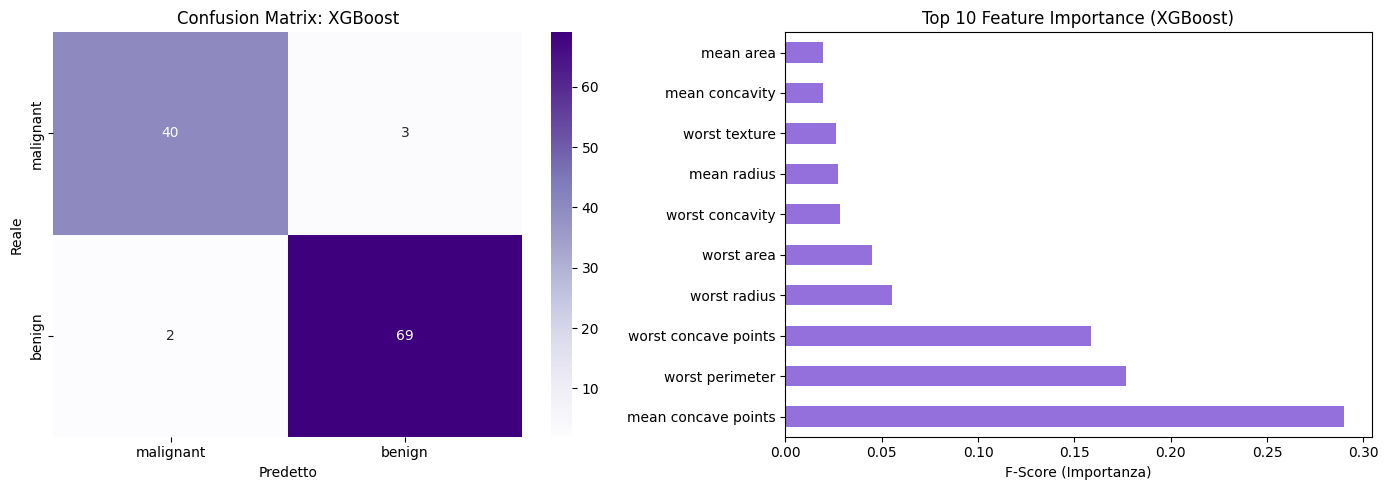

Accuratezza XGBoost: 95.61%

Report Tecnico:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# È necessario installare xgboost: !pip install xgboost
from xgboost import XGBClassifier

# 1. Preparazione dei dati
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split Train/Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Configurazione del modello XGBoost
# I parametri chiave:
# n_estimators: numero di alberi sequenziali
# learning_rate (eta): quanto pesano le correzioni di ogni nuovo albero (previene overfitting)
# max_depth: profondità di ogni albero
# gamma: parametro di regolarizzazione (minima riduzione della perdita per fare uno split)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss', # Evita i warning e specifica la funzione di costo
    random_state=42
)

# 3. Addestramento
xgb_model.fit(X_train, y_train)

# 4. Predizione
y_pred = xgb_model.predict(X_test)

# --- VISUALIZZAZIONE RISULTATI ---
plt.figure(figsize=(14, 5))

# Grafico 1: Matrice di Confusione
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Predetto')
plt.ylabel('Reale')

# Grafico 2: Feature Importance di XGBoost
plt.subplot(1, 2, 2)
# XGBoost ha un suo metodo per calcolare l'importanza delle feature
feat_importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.xlabel('F-Score (Importanza)')

plt.tight_layout()
plt.show()

# Metriche finali
print(f"Accuratezza XGBoost: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nReport Tecnico:")
print(classification_report(y_test, y_pred, target_names=data.target_names))



E se per puro caso il tuo Test Set contenesse solo i casi più facili da prevedere? Avresti un'accuratezza altissima, ma il modello farebbe disastri nel mondo reale. La **Cross-Validation** (Validazione Incrociata) risolve questo problema, assicurandosi che ogni singolo dato venga usato sia per l'addestramento che per il test.

---

### 1. Il concetto di K-Fold Cross Validation

La tecnica più comune è il **K-Fold**. Ecco come funziona il processo "passo dopo passo":

1. **Dividi:** Prendi il tuo dataset originale e dividilo in  parti uguali (chiamate **Folds**). Solitamente  o .
2. **Itera:** L'algoritmo esegue  cicli di addestramento:
* Nel primo ciclo, il Fold 1 è il Test Set, e gli altri (2, 3, 4, 5) sono il Train Set.
* Nel secondo ciclo, il Fold 2 è il Test Set, e gli altri sono il Train Set.
* ...e così via finché ogni Fold non è stato usato esattamente una volta come Test Set.


3. **Media:** Alla fine, avrai  punteggi diversi (es. 5 valori di RMSE). Calcoli la **media** e la **deviazione standard** di questi punteggi.

---

### 2. Perché è indispensabile per un esperto?

* **Affidabilità Totale:** Non ti fidi più di un singolo numero, ma di una distribuzione. Se l'accuratezza è 0.90 in tutti i fold, il modello è stabile. Se oscilla tra 0.70 e 0.95, il modello è instabile (alta varianza).
* **Massimo utilizzo dei dati:** È fondamentale quando hai pochi dati (come nel caso di Iris o Breast Cancer), perché ti permette di testare il modello su **tutto** il dataset senza "buttare via" una parte fissa per il test.
* **Tuning degli Iperparametri:** Quando ottimizziamo XGBoost o SVM, usiamo la CV per decidere quale `learning_rate` o `C` è migliore. Non vogliamo i parametri che funzionano meglio su un solo split, ma quelli che funzionano meglio in media su tutto il dataset.

---

### 3. Varianti Specializzate

#### Stratified K-Fold (Per la Classificazione)

Se hai un dataset sbilanciato (es. 90% tumori benigni, 10% maligni), rischi che un Fold contenga solo casi benigni. La versione **Stratified** assicura che in ogni Fold la proporzione delle classi rimanga la stessa del dataset originale (es. sempre il 10% di maligni).

#### Leave-One-Out (LOOCV)

È il caso estremo dove  è uguale al numero di righe del dataset. Ogni volta usi tutto il dataset tranne **una sola riga** per il test. È precisissimo ma richiede una potenza di calcolo enorme (se hai 1 milione di righe, devi addestrare il modello 1 milione di volte!).

---

### 4. La Matematica della Validazione

Il punteggio finale della Cross-Validation è dato dalla media aritmetica dei risultati dei singoli fold:

$$CV_{(k)} = \frac{1}{k} \sum_{i=1}^{k} Metric_i$$

Dove $Metric_i$ è il punteggio (es. accuratezza o MSE) ottenuto nell'i-esimo ciclo.



c:\Users\mbagn\anaconda3\envs\pytorch\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:04:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mbagn\anaconda3\envs\pytorch\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:04:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mbagn\anaconda3\envs\pytorch\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:04:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mbagn\anaconda3\envs\pytorch\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:04:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "

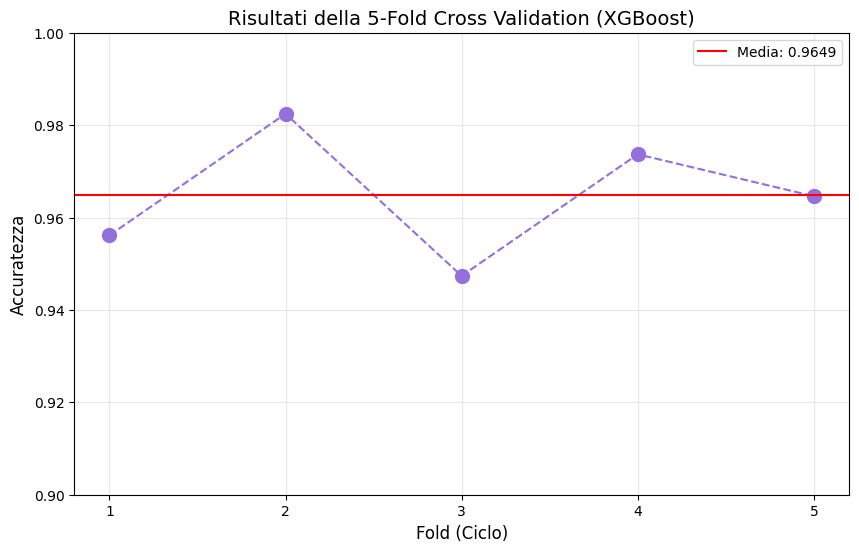

Punteggi per ogni Fold: [0.95614035 0.98245614 0.94736842 0.97368421 0.96460177]
Accuratezza Media: 96.49%
Deviazione Standard: 1.24%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBClassifier

# 1. Caricamento dati
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Configurazione del modello (stessi parametri di prima)
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# 3. Configurazione del K-Fold
# Usiamo 5-Fold (il dataset viene diviso in 5 parti)
# shuffle=True assicura che i dati siano mescolati prima di dividerli
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Esecuzione della Cross-Validation
# Usiamo 'accuracy' come metrica, ma potremmo usare 'roc_auc' o 'f1'
cv_results = cross_val_score(xgb_model, X, y, cv=kf, scoring='accuracy')

# --- VISUALIZZAZIONE DEI RISULTATI DELLA CV ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_results, marker='o', linestyle='--', color='mediumpurple', markersize=10)
plt.axhline(y=cv_results.mean(), color='red', label=f'Media: {cv_results.mean():.4f}')

plt.title('Risultati della 5-Fold Cross Validation (XGBoost)', fontsize=14)
plt.xlabel('Fold (Ciclo)', fontsize=12)
plt.ylabel('Accuratezza', fontsize=12)
plt.xticks(range(1, 6))
plt.ylim(0.9, 1.0) # Zoom sull'area di interesse
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Statistiche Finali
print(f"Punteggi per ogni Fold: {cv_results}")
print(f"Accuratezza Media: {cv_results.mean() * 100:.2f}%")
print(f"Deviazione Standard: {cv_results.std() * 100:.2f}%")

Addestrare un modello come XGBoost senza ottimizzare i parametri è come comprare una Ferrari e guidarla solo in prima marcia. Fino ad ora abbiamo "girato le manopole" a mano, ma nel mondo reale usiamo degli algoritmi che lo fanno per noi.

Ecco la teoria dietro le tre strategie principali per l'**Hyperparameter Tuning**.

---

## 1. Grid Search: L'approccio "Forza Bruta"

Il **Grid Search** è l'approccio più semplice ed esaustivo. Definisci una "griglia" di valori per ogni parametro e il computer prova **ogni singola combinazione possibile**.

* **Come funziona:** Se vuoi provare 3 valori di `learning_rate` e 3 valori di `max_depth`, il Grid Search eseguirà  addestramenti (moltiplicati per i fold della Cross-Validation).
* **Vantaggio:** È garantito che troverai la combinazione migliore all'interno della griglia definita.
* **Svantaggio:** Soffre della **maledizione della dimensionalità**. Se aggiungi un quarto parametro con 5 opzioni, il tempo di calcolo esplode esponenzialmente.

---

## 2. Randomized Search: Lo stratega statistico

Invece di provare tutto, il **Randomized Search** estrae campioni casuali dallo spazio dei parametri.

* **Il segreto:** James Bergstra e Yoshua Bengio hanno dimostrato che non tutti gli iperparametri sono ugualmente importanti. Il Grid Search perde tempo a testare variazioni su parametri "inutili". Il Random Search, muovendosi a caso, ha più probabilità di esplorare valori diversi per i parametri davvero critici.
* **Vantaggio:** Molto più veloce. Puoi definire un budget di tempo (es. "prova solo 50 combinazioni casuali") e spesso trovi un risultato quasi identico al Grid Search in una frazione del tempo.
* **Svantaggio:** Non garantisce di trovare l'ottimo assoluto, poiché potrebbe "saltare" per puro caso la combinazione perfetta.

---

## 3. Bayesian Optimization: L'intelligenza sequenziale

Questo è l'approccio più avanzato. Invece di tirare a indovinare (Random) o provare tutto (Grid), l'ottimizzazione bayesiana **impara dai risultati precedenti**.

* **Come funziona:** Costruisce un modello probabilistico (chiamato *Surrogate Model*, spesso un Processo Gaussiano) che cerca di mappare la relazione tra parametri e punteggio del modello.
* **La Logica:** L'algoritmo sceglie la prossima combinazione da testare bilanciando due concetti:
1. **Exploitation (Sfruttamento):** Prova valori vicini a quelli che hanno già dato buoni risultati.
2. **Exploration (Esplorazione):** Prova valori in zone dello spazio dei parametri ancora sconosciute.


* **Vantaggio:** È incredibilmente efficiente. Trova parametri migliori del Grid Search facendo molti meno tentativi.
* **Svantaggio:** È più complesso da implementare (richiede librerie come `Optuna` o `Hyperopt`).

---

## Tabella Comparativa

| Metodo | Approccio | Velocità | Precisione | Quando usarlo |
| --- | --- | --- | --- | --- |
| **Grid Search** | Sistematico | Lenta | Alta | Spazi di ricerca molto piccoli. |
| **Random Search** | Casuale | Veloce | Buona | Grandi spazi di ricerca o poco tempo. |
| **Bayesian Opt.** | Sequenziale | Ottima | Massima | Modelli pesanti (XGBoost, Deep Learning). |

---

### Un concetto chiave: Lo Spazio di Ricerca

Per i parametri che variano su ordini di grandezza (come il `learning_rate`), non usiamo distribuzioni lineari ma **logaritmiche**. È molto più utile testare la differenza tra  e  che quella tra  e .

> **Nota dell'AI:** Molti principianti dimenticano che l'ottimizzazione degli iperparametri fatta senza **Cross-Validation** è inutile: troveresti solo i parametri che fanno overfitting sul singolo split di training!



Dataset caricato: 569 campioni, 30 caratteristiche.
Inizio ricerca parametri ottimali (RandomizedSearchCV)...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

--- RISULTATI RICERCA ---
Miglior accuratezza in CV: 0.9802
Migliori parametri:
  - colsample_bytree: 0.7801997007878172
  - gamma: 0.006632480579933264
  - learning_rate: 0.19844035113697056
  - max_depth: 8
  - n_estimators: 341
  - reg_lambda: 1.7708330050798322
  - subsample: 0.6063865008880857

Accuratezza finale sul Test Set: 0.9737


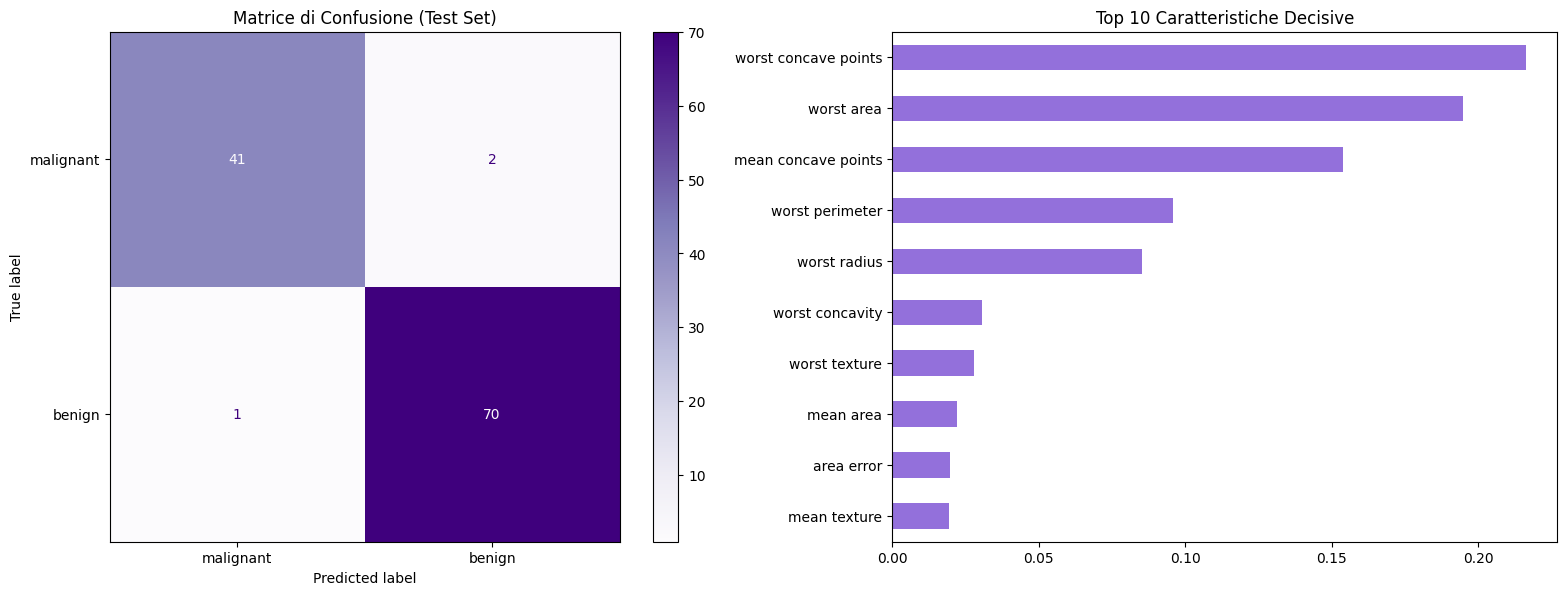


--- REPORT DI CLASSIFICAZIONE ---
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset e Preprocessing
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import uniform, randint

# Modello e Metriche
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# 1. CARICAMENTO DATI
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split iniziale per avere un set di test "puro" (mai visto dal modello)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset caricato: {X.shape[0]} campioni, {X.shape[1]} caratteristiche.")

# 2. DEFINIZIONE DELLO SPAZIO DI RICERCA
# Creiamo distribuzioni di probabilità per gli iperparametri
param_dist = {
    'n_estimators': randint(100, 500),         # Numero di alberi (boosting rounds)
    'max_depth': randint(3, 10),              # Profondità massima dell'albero
    'learning_rate': uniform(0.01, 0.2),      # Passo di apprendimento (Shrinkage)
    'gamma': uniform(0, 0.5),                 # Regolarizzazione (min_split_loss)
    'subsample': uniform(0.6, 0.4),           # Percentuale di righe per ogni albero
    'colsample_bytree': uniform(0.6, 0.4),    # Percentuale di feature per ogni albero
    'reg_lambda': uniform(1, 2)               # Regolarizzazione L2 (pesi delle foglie)
}

# 3. CONFIGURAZIONE XGBOOST
# Nota: use_label_encoder è rimosso per evitare warning nelle nuove versioni
xgb = XGBClassifier(
    eval_metric='logloss', 
    random_state=42
)

# 4. RANDOMIZED SEARCH CON CROSS-VALIDATION
# Prova 20 combinazioni casuali, ognuna validata su 5 fold
print("Inizio ricerca parametri ottimali (RandomizedSearchCV)...")
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,               # Numero di tentativi casuali
    scoring='accuracy',      # Obiettivo: massimizzare l'accuratezza
    cv=5,                    # 5-Fold Cross Validation
    verbose=1,               # Mostra i progressi
    n_jobs=-1,               # Usa tutta la potenza della CPU
    random_state=42
)

# Addestramento sul set di training
random_search.fit(X_train, y_train)

# 5. ESTRAZIONE DEL MIGLIOR MODELLO
best_model = random_search.best_estimator_
print("\n--- RISULTATI RICERCA ---")
print(f"Miglior accuratezza in CV: {random_search.best_score_:.4f}")
print("Migliori parametri:")
for p, v in random_search.best_params_.items():
    print(f"  - {p}: {v}")

# 6. VALUTAZIONE FINALE SUL TEST SET (Dati mai visti)
y_pred = best_model.predict(X_test)
final_acc = accuracy_score(y_test, y_pred)

print(f"\nAccuratezza finale sul Test Set: {final_acc:.4f}")

# 7. VISUALIZZAZIONE: MATRICE DI CONFUSIONE E FEATURE IMPORTANCE
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Matrice di Confusione
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, 
    display_labels=data.target_names, 
    cmap='Purples', ax=ax1
)
ax1.set_title("Matrice di Confusione (Test Set)")

# Feature Importance (Top 10)
feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='mediumpurple', ax=ax2)
ax2.set_title("Top 10 Caratteristiche Decisive")

plt.tight_layout()
plt.show()

# 8. REPORT DETTAGLIATO
print("\n--- REPORT DI CLASSIFICAZIONE ---")
print(classification_report(y_test, y_pred, target_names=data.target_names))

## Utilizziamo optuna per Bayesian Optimization

[I 2026-02-06 12:12:56,370] A new study created in memory with name: no-name-cdf39b47-6cfc-44d9-8357-8307dc011075



[INFO] Avvio Ottimizzazione Bayesiana...


[I 2026-02-06 12:12:56,872] Trial 0 finished with value: 0.964835164835165 and parameters: {'n_estimators': 174, 'max_depth': 4, 'learning_rate': 0.016623839136863917, 'gamma': 0.008160080979331576, 'subsample': 0.9391726403279338, 'colsample_bytree': 0.5061544591164143, 'reg_lambda': 0.010769880221013843, 'reg_alpha': 1.1136031125520497e-08}. Best is trial 0 with value: 0.964835164835165.
[I 2026-02-06 12:12:58,182] Trial 1 finished with value: 0.964835164835165 and parameters: {'n_estimators': 519, 'max_depth': 10, 'learning_rate': 0.0316384270213364, 'gamma': 1.348018135611313e-08, 'subsample': 0.9321985063733893, 'colsample_bytree': 0.9274800302553308, 'reg_lambda': 4.4061638202862445e-06, 'reg_alpha': 1.0376291546260712e-05}. Best is trial 0 with value: 0.964835164835165.
[I 2026-02-06 12:12:59,096] Trial 2 finished with value: 0.9692307692307693 and parameters: {'n_estimators': 459, 'max_depth': 8, 'learning_rate': 0.11463158586796668, 'gamma': 1.1963499220634572e-07, 'subsample'


 RISULTATI OTTIMIZZAZIONE 
Miglior accuratezza trovata in CV: 0.9780

Migliori parametri identificati:
  - n_estimators: 391
  - max_depth: 7
  - learning_rate: 0.25905263733610184
  - gamma: 3.1746562528901774e-06
  - subsample: 0.7858863493608561
  - colsample_bytree: 0.8048296665659038
  - reg_lambda: 0.5732136293800766
  - reg_alpha: 0.00019355837411072006


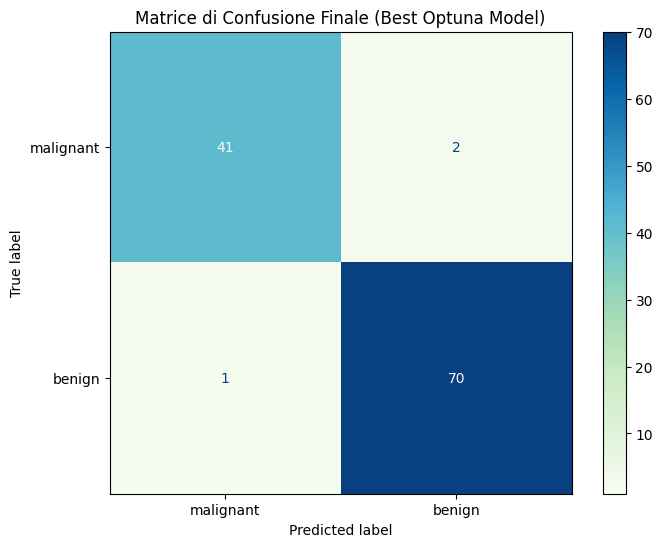


 REPORT TECNICO FINALE 
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
import pandas as pd
import numpy as np
import optuna
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Configurazione del logging di Optuna per essere "chiacchierone" (Verbose)
import logging
optuna.logging.set_verbosity(optuna.logging.INFO)

# 1. CARICAMENTO E PREPARAZIONE DATI
data = load_breast_cancer()
X, y = data.data, data.target
# Usiamo uno split 80/20. Il test set rimane "sacro" per la valutazione finale.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. DEFINIZIONE DELLA FUNZIONE OBIETTIVO
def objective(trial):
    # Spazio di ricerca definito con distribuzioni suggerite
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        # Usiamo scale logaritmiche per parametri che variano su diversi ordini di grandezza
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'eval_metric': 'logloss',
        'random_state': 42
    }

    # Inizializzazione del modello con i parametri del "tentativo" corrente
    model = xgb.XGBClassifier(**param)
    
    # Cross-Validation a 5 fold sul training set
    # L'obiettivo di Optuna è massimizzare la media di questi 5 punteggi
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    
    return score

# 3. CREAZIONE DELLO STUDIO E OTTIMIZZAZIONE
print("\n[INFO] Avvio Ottimizzazione Bayesiana...")
# 'maximize' perché vogliamo l'accuratezza più alta
study = optuna.create_study(direction='maximize')

# Eseguiamo 50 tentativi (Trial)
study.optimize(objective, n_trials=50)

# 4. ANALISI DEI RISULTATI (Correzione Errore best_params_)
print("\n" + "="*30)
print(" RISULTATI OTTIMIZZAZIONE ")
print("="*30)
print(f"Miglior accuratezza trovata in CV: {study.best_value:.4f}")
print("\nMigliori parametri identificati:")

# NOTA: In Optuna si usa .best_params (senza underscore finale)
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

# 5. ADDESTRAMENTO DEL MODELLO "CAMPIONE"
# Ricostruiamo il modello usando la scompattazione del dizionario dei parametri migliori
best_model = xgb.XGBClassifier(**study.best_params, eval_metric='logloss', random_state=42)
best_model.fit(X_train, y_train)

# 6. VALUTAZIONE FINALE SUL TEST SET (Dati mai visti)
y_pred = best_model.predict(X_test)

# Visualizzazione della Matrice di Confusione
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, 
    display_labels=data.target_names, 
    cmap='GnBu', ax=ax
)
plt.title("Matrice di Confusione Finale (Best Optuna Model)")
plt.grid(False) # Rimuove le linee della griglia per chiarezza
plt.show()

# 7. REPORT FINALE DI PERFORMANCE
print("\n" + "="*30)
print(" REPORT TECNICO FINALE ")
print("="*30)
print(classification_report(y_test, y_pred, target_names=data.target_names))

## Applichiamo tutto al dataset origiale adesso

[I 2026-02-06 12:22:42,320] A new study created in memory with name: no-name-163c3254-7e00-45f5-87b5-0fb6e23231b2


[INFO] Avvio ricerca bayesiana con K-Fold...


Best trial: 0. Best value: 0.905149:   3%|▎         | 1/30 [00:05<02:35,  5.35s/it]

[I 2026-02-06 12:22:47,666] Trial 0 finished with value: 0.9051493762865108 and parameters: {'n_estimators': 907, 'max_depth': 7, 'learning_rate': 0.012587904827010112, 'subsample': 0.6520130848008459, 'colsample_bytree': 0.7178907085654261, 'gamma': 4.7696159207333085e-08, 'reg_lambda': 5.066861896742019}. Best is trial 0 with value: 0.9051493762865108.


Best trial: 0. Best value: 0.905149:   7%|▋         | 2/30 [00:12<03:01,  6.49s/it]

...

[I 2026-02-06 12:23:25,569] Trial 27 finished with value: 0.895487930078738 and parameters: {'n_estimators': 267, 'max_depth': 4, 'learning_rate': 0.027503199647328704, 'subsample': 0.9541201575457049, 'colsample_bytree': 0.8647700937941868, 'gamma': 0.07291850061915138, 'reg_lambda': 1.6030932086978587}. Best is trial 5 with value: 0.9087434220009207.


Best trial: 5. Best value: 0.908743:  97%|█████████▋| 29/30 [00:45<00:01,  1.18s/it]

[I 2026-02-06 12:23:27,531] Trial 28 finished with value: 0.9028861948368101 and parameters: {'n_estimators': 361, 'max_depth': 6, 'learning_rate': 0.03867873660628353, 'subsample': 0.7957056151011846, 'colsample_bytree': 0.9970096348511801, 'gamma': 1.2008354427598802e-05, 'reg_lambda': 3.565433413896835}. Best is trial 5 with value: 0.9087434220009207.


Best trial: 5. Best value: 0.908743: 100%|██████████| 30/30 [00:46<00:00,  1.55s/it]


[I 2026-02-06 12:23:28,694] Trial 29 finished with value: 0.9068347746333574 and parameters: {'n_estimators': 487, 'max_depth': 5, 'learning_rate': 0.05891273096206357, 'subsample': 0.7332057914286676, 'colsample_bytree': 0.7147709672453926, 'gamma': 0.0036939399630911093, 'reg_lambda': 4.885047854909589}. Best is trial 5 with value: 0.9087434220009207.

Miglior R2 in Cross-Validation: 0.9087

 PERFORMANCE FINALE (Real World) 
R^2 Score: 0.8498
Errore Medio (MAE): $13,241.36


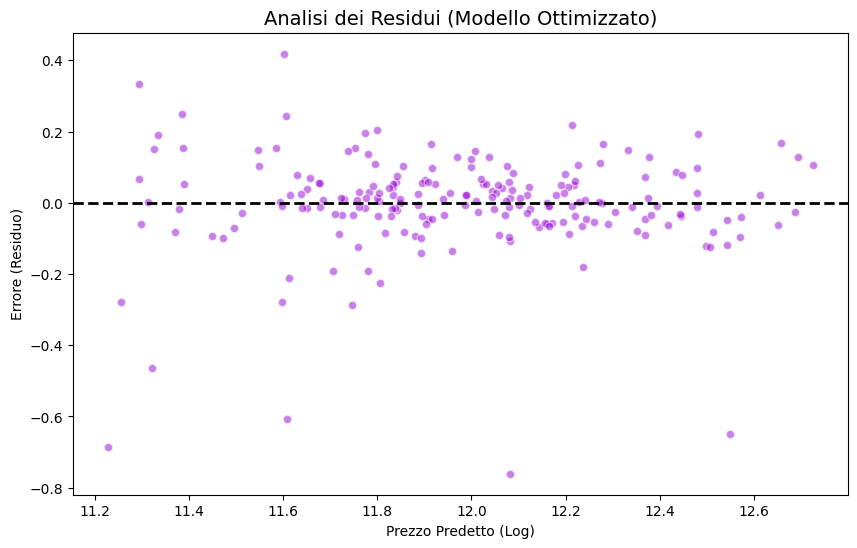

In [ ]:
import optuna
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. PREPARAZIONE DATI (SINCRONIZZATI)
# Assicuriamoci che y_houses e X_trees_scaled siano allineati (1022 righe)
y_houses = np.log1p(df_trees['SalePrice'])
X_train, X_test, y_train, y_test = train_test_split(
    X_trees_scaled, y_houses, test_size=0.2, random_state=42
)

# Convertiamo in NumPy per velocità e compatibilità
X_train_np = np.asarray(X_train)
y_train_np = np.asarray(y_train).ravel()

# 2. DEFINIZIONE OBJECTIVE FUNCTION PER OPTUNA
def objective(trial):
    # Spazio di ricerca per la regressione
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 0.5, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }
    
    # Inizializziamo il regressore
    regressor = xgb.XGBRegressor(**params)
    
    # Integriamo il K-Fold (5 fold) per validare ogni set di parametri
    # Usiamo R2 come metrica da massimizzare
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(regressor, X_train_np, y_train_np, cv=kf, scoring='r2').mean()
    
    return score

# 3. AVVIO OTTIMIZZAZIONE
print("[INFO] Avvio ricerca bayesiana con K-Fold...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

# 4. RISULTATI E ADDESTRAMENTO FINALE
print(f"\nMiglior R2 in Cross-Validation: {study.best_value:.4f}")

# Alleniamo il modello finale con i parametri migliori su TUTTO il training set
best_model = xgb.XGBRegressor(**study.best_params, random_state=42)
best_model.fit(X_train_np, y_train_np)

# 5. VALUTAZIONE SUL TEST SET
y_pred_log = best_model.predict(np.asarray(X_test))
y_test_real = np.expm1(y_test)       # Torniamo ai Dollari
y_pred_real = np.expm1(y_pred_log)   # Torniamo ai Dollari

# 6. METRICHE FINALI IN DOLLARI
final_mae = mean_absolute_error(y_test_real, y_pred_real)
final_r2 = r2_score(y_test, y_pred_log)

print("\n" + "="*35)
print(f" PERFORMANCE FINALE (Real World) ")
print("="*35)
print(f"R^2 Score: {final_r2:.4f}")
print(f"Errore Medio (MAE): ${final_mae:,.2f}")

# 7. GRAFICO DEI RESIDUI FINALE
plt.figure(figsize=(10, 6))
residuals = y_test - y_pred_log
plt.scatter(y_pred_log, residuals, alpha=0.5, color='darkviolet', edgecolors='w')
plt.axhline(y=0, color='black', linestyle='--', lw=2)
plt.title("Analisi dei Residui (Modello Ottimizzato)", fontsize=14)
plt.xlabel("Prezzo Predetto (Log)")
plt.ylabel("Errore (Residuo)")
plt.show()

## Confronto con Linear Regression

[I 2026-02-06 12:23:40,052] A new study created in memory with name: no-name-156d5fff-fad2-401c-b554-84798804a38f


[INFO] Ottimizzazione ElasticNet (L1/L2)...


Best trial: 1. Best value: 0.917892:  10%|█         | 3/30 [00:00<00:03,  6.90it/s]

[I 2026-02-06 12:23:40,434] Trial 0 finished with value: 0.9074885387303875 and parameters: {'alpha': 2.7464950208614862e-05, 'l1_ratio': 0.6232489153202356}. Best is trial 0 with value: 0.9074885387303875.
[I 2026-02-06 12:23:40,479] Trial 1 finished with value: 0.9178917577752594 and parameters: {'alpha': 0.01836535365527566, 'l1_ratio': 0.19088888951784744}. Best is trial 1 with value: 0.9178917577752594.
[I 2026-02-06 12:23:40,558] Trial 2 finished with value: 0.9158415283336346 and parameters: {'alpha': 0.00104064123762168, 'l1_ratio': 0.9903402408934918}. Best is trial 1 with value: 0.9178917577752594.
[I 2026-02-06 12:23:40,588] Trial 3 finished with value: 0.08846571822035332 and parameters: {'alpha': 0.4131463414716279, 'l1_ratio': 0.6617674154919972}. Best is trial 1 with value: 0.9178917577752594.


Best trial: 5. Best value: 0.918589:  20%|██        | 6/30 [00:00<00:01, 12.72it/s]

...

[I 2026-02-06 12:23:43,225] Trial 24 finished with value: 0.885149172699327 and parameters: {'alpha': 0.056148429948830084, 'l1_ratio': 0.39420875231853597}. Best is trial 5 with value: 0.9185886711263539.


Best trial: 5. Best value: 0.918589:  93%|█████████▎| 28/30 [00:03<00:00, 10.62it/s]

[I 2026-02-06 12:23:43,485] Trial 25 finished with value: 0.9113639556185487 and parameters: {'alpha': 0.0006291002117529697, 'l1_ratio': 0.08933097092991703}. Best is trial 5 with value: 0.9185886711263539.
[I 2026-02-06 12:23:43,520] Trial 26 finished with value: 0.7350945717029749 and parameters: {'alpha': 0.12620989323278975, 'l1_ratio': 0.7735498429337799}. Best is trial 5 with value: 0.9185886711263539.
[I 2026-02-06 12:23:43,575] Trial 27 finished with value: 0.9153572511586796 and parameters: {'alpha': 0.004413508546790564, 'l1_ratio': 0.40362999441308606}. Best is trial 5 with value: 0.9185886711263539.
[I 2026-02-06 12:23:43,608] Trial 28 finished with value: 0.6801611309031121 and parameters: {'alpha': 0.4684277256681365, 'l1_ratio': 0.22771196565562707}. Best is trial 5 with value: 0.9185886711263539.


Best trial: 5. Best value: 0.918589: 100%|██████████| 30/30 [00:03<00:00,  7.91it/s]


[I 2026-02-06 12:23:43,843] Trial 29 finished with value: 0.9139524591188684 and parameters: {'alpha': 0.0002210812036067081, 'l1_ratio': 0.6078328391181754}. Best is trial 5 with value: 0.9185886711263539.

--- PERFORMANCE LINEARE (Ottimizzata) ---
Migliori Parametri: {'alpha': 0.0066937877536919765, 'l1_ratio': 0.6765998511854169}
R^2 Score: 0.8697
MAE: $12,562.08


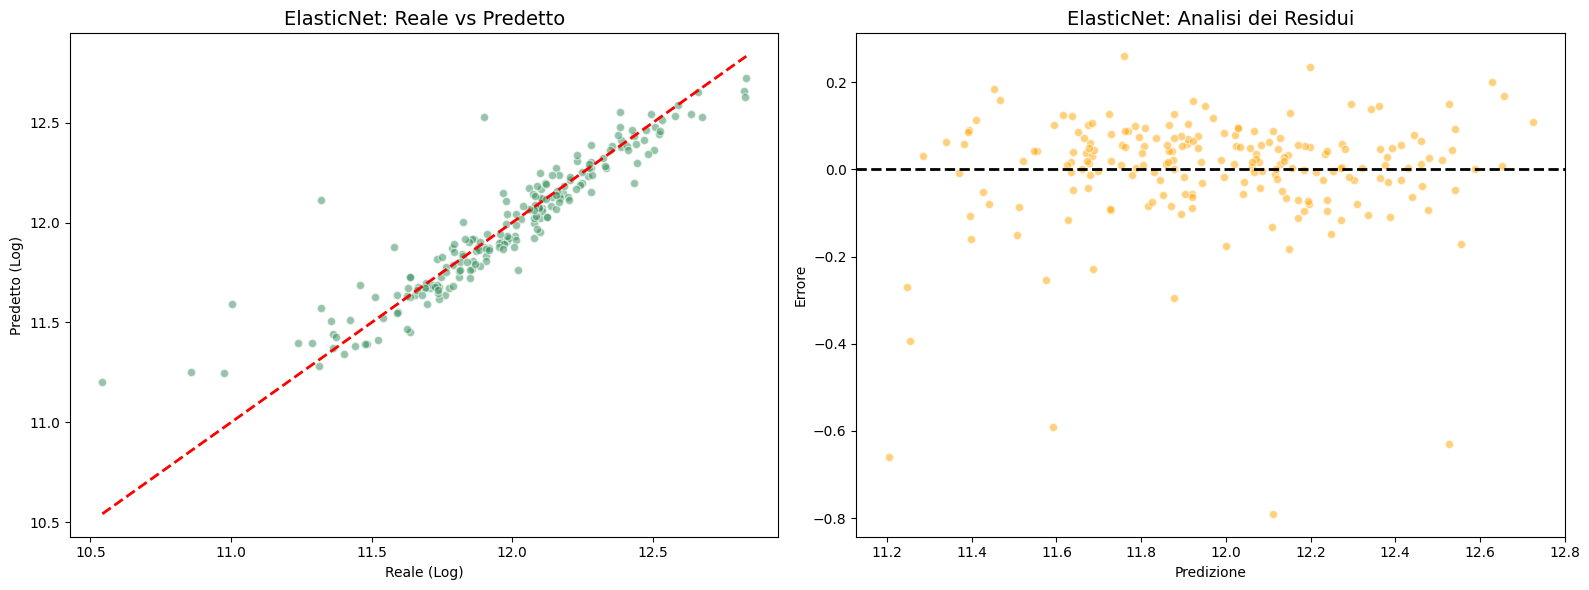

In [ ]:
import optuna
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 1. PREPARAZIONE DATI (Standard Scaled)
# Usiamo y_houses (log-prezzo) sincronizzato precedentemente
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_standard_scaled, y_houses, test_size=0.2, random_state=42
)

# 2. DEFINIZIONE OBJECTIVE PER OPTUNA
def objective_linear(trial):
    # Parametri per ElasticNet
    params = {
        'alpha': trial.suggest_float('alpha', 1e-5, 10.0, log=True), # Forza della regolarizzazione
        'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),      # Bilanciamento L1 vs L2
        'max_iter': 10000,
        'random_state': 42
    }
    
    regr = ElasticNet(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Valutazione con R2
    score = cross_val_score(regr, X_train_lin, y_train_lin, cv=kf, scoring='r2').mean()
    return score

# 3. OTTIMIZZAZIONE
print("[INFO] Ottimizzazione ElasticNet (L1/L2)...")
study_lin = optuna.create_study(direction='maximize')
study_lin.optimize(objective_linear, n_trials=30, show_progress_bar=True)

# 4. ADDESTRAMENTO MODELLO BEST
best_lin_model = ElasticNet(**study_lin.best_params, max_iter=10000, random_state=42)
best_lin_model.fit(X_train_lin, y_train_lin)

# 5. PREDIZIONE E CONVERSIONE IN DOLLARI
y_pred_log_lin = best_lin_model.predict(X_test_lin)
y_test_real = np.expm1(y_test_lin)
y_pred_real_lin = np.expm1(y_pred_log_lin)

# 6. METRICHE
mae_lin = mean_absolute_error(y_test_real, y_pred_real_lin)
r2_lin = r2_score(y_test_lin, y_pred_log_lin)

print(f"\n--- PERFORMANCE LINEARE (Ottimizzata) ---")
print(f"Migliori Parametri: {study_lin.best_params}")
print(f"R^2 Score: {r2_lin:.4f}")
print(f"MAE: ${mae_lin:,.2f}")

# 7. VISUALIZZAZIONE CONFRONTO
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Grafico 1: Predizioni vs Reale
ax1.scatter(y_test_lin, y_pred_log_lin, alpha=0.5, color='seagreen', edgecolors='w')
ax1.plot([y_test_lin.min(), y_test_lin.max()], [y_test_lin.min(), y_test_lin.max()], 'r--', lw=2)
ax1.set_title("ElasticNet: Reale vs Predetto", fontsize=14)
ax1.set_xlabel("Reale (Log)")
ax1.set_ylabel("Predetto (Log)")

# Grafico 2: Residui
residuals_lin = y_test_lin - y_pred_log_lin
ax2.scatter(y_pred_log_lin, residuals_lin, alpha=0.5, color='orange', edgecolors='w')
ax2.axhline(y=0, color='black', linestyle='--', lw=2)
ax2.set_title("ElasticNet: Analisi dei Residui", fontsize=14)
ax2.set_xlabel("Predizione")
ax2.set_ylabel("Errore")

plt.tight_layout()
plt.show()

## Perché la linear è meglio?

Forse il problema è lineare, o forse possiamo far gestire tutto a xgboost comprese le variabili categoriche e i nan!


c:\Users\mbagn\anaconda3\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-02-06 12:41:01,737] A new study created in memory with name: no-name-15235375-0619-4685-9412-71e29615f3c9


Dataset pronto: 1168 campioni per l'addestramento.
[INFO] Avvio ottimizzazione su dataset completo...


Best trial: 0. Best value: 0.89256:   3%|▎         | 1/30 [00:05<02:38,  5.45s/it]

[I 2026-02-06 12:41:07,186] Trial 0 finished with value: 0.8925600402449863 and parameters: {'n_estimators': 934, 'max_depth': 5, 'learning_rate': 0.04324886374426734, 'subsample': 0.8385686490189099, 'colsample_bytree': 0.8751611516666422, 'gamma': 2.4152658701404622e-08}. Best is trial 0 with value: 0.8925600402449863.


Best trial: 0. Best value: 0.89256:   7%|▋         | 2/30 [00:11<02:36,  5.58s/it]

...

[I 2026-02-06 12:42:32,979] Trial 27 finished with value: 0.9027487177146204 and parameters: {'n_estimators': 489, 'max_depth': 5, 'learning_rate': 0.048778104333232146, 'subsample': 0.7124612162953056, 'colsample_bytree': 0.5774026281226112, 'gamma': 5.218812274756659e-05}. Best is trial 21 with value: 0.9068204051096279.


Best trial: 21. Best value: 0.90682:  97%|█████████▋| 29/30 [01:36<00:03,  3.50s/it]

[I 2026-02-06 12:42:37,876] Trial 28 finished with value: 0.8929380623097802 and parameters: {'n_estimators': 804, 'max_depth': 7, 'learning_rate': 0.06567686310990395, 'subsample': 0.6442793282770073, 'colsample_bytree': 0.631993274019733, 'gamma': 1.4939888360733073e-06}. Best is trial 21 with value: 0.9068204051096279.


Best trial: 21. Best value: 0.90682: 100%|██████████| 30/30 [01:40<00:00,  3.35s/it]


[I 2026-02-06 12:42:42,094] Trial 29 finished with value: 0.8952471986540015 and parameters: {'n_estimators': 999, 'max_depth': 4, 'learning_rate': 0.09963572270326582, 'subsample': 0.7877658398971897, 'colsample_bytree': 0.518325742121289, 'gamma': 1.8554878134945098e-07}. Best is trial 21 with value: 0.9068204051096279.

Miglior R2 trovato in CV: 0.9068

--- PERFORMANCE FINALE (Full Dataset) ---
R^2 Score sul Test Set: 0.9108
Errore Medio Reale (MAE): $14,221.23


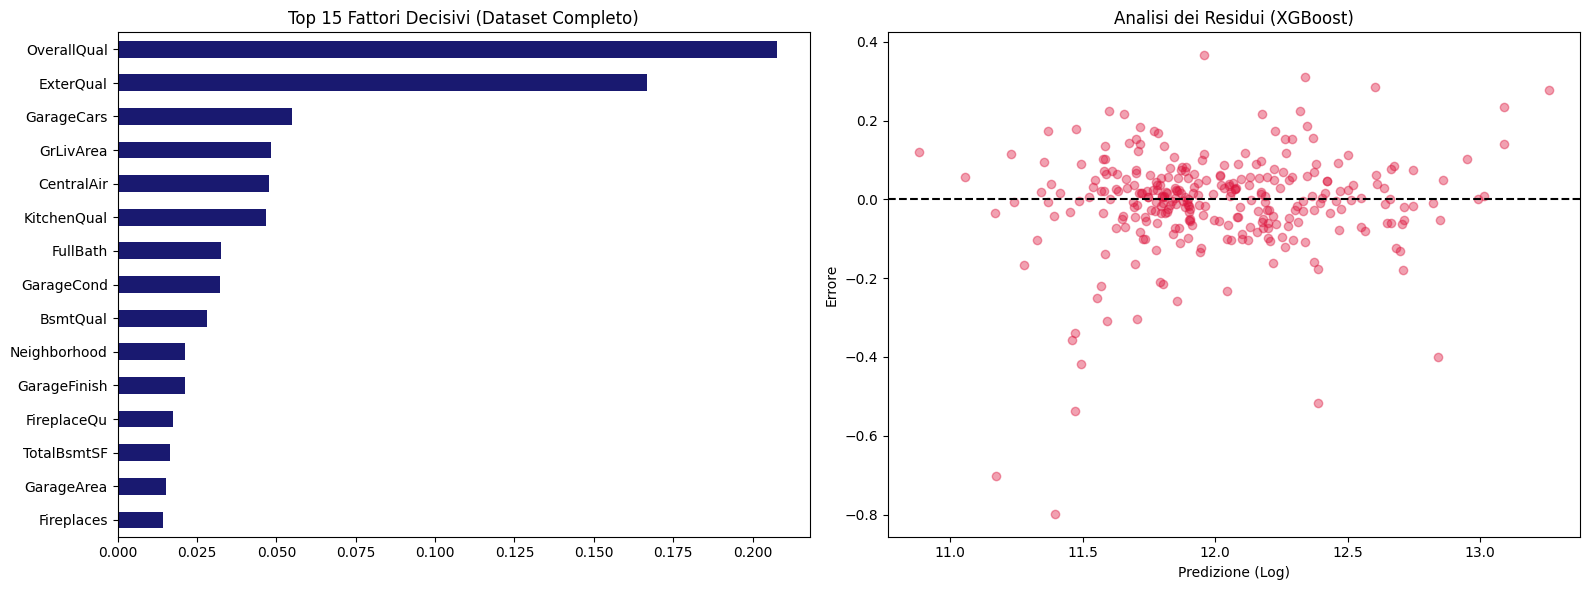

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. CARICAMENTO E PREPARAZIONE (Senza filtri outlier)
from sklearn.datasets import fetch_openml
housing = fetch_openml(name="house_prices", as_frame=True)
df = housing.frame

# Conversione in 'category' per permettere a XGBoost di gestire il testo autonomamente
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')

# Prep Target e Feature
y = np.log1p(df['SalePrice'])
X = df.drop('SalePrice', axis=1)

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset pronto: {X_train.shape[0]} campioni per l'addestramento.")

# 2. DEFINIZIONE OBJECTIVE FUNCTION
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'tree_method': 'hist',      # Algoritmo ottimizzato per dati categorici
        'enable_categorical': True, # Attiva la gestione nativa delle categorie
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = xgb.XGBRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Cross-Validation basata su R2
    score = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2').mean()
    return score

# 3. OTTIMIZZAZIONE BAYESIANA
print("[INFO] Avvio ottimizzazione su dataset completo...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

# 4. ADDESTRAMENTO MODELLO FINALE
print(f"\nMiglior R2 trovato in CV: {study.best_value:.4f}")
final_model = xgb.XGBRegressor(**study.best_params, tree_method='hist', enable_categorical=True, random_state=42)
final_model.fit(X_train, y_train)

# 5. VALUTAZIONE IN DOLLARI
y_pred_log = final_model.predict(X_test)
y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

mae_dollars = mean_absolute_error(y_test_real, y_pred_real)
r2_test = r2_score(y_test, y_pred_log)

print(f"\n--- PERFORMANCE FINALE (Full Dataset) ---")
print(f"R^2 Score sul Test Set: {r2_test:.4f}")
print(f"Errore Medio Reale (MAE): ${mae_dollars:,.2f}")

# 6. VISUALIZZAZIONE DIAGNOSTICA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Feature Importance
feat_importances = pd.Series(final_model.feature_importances_, index=X.columns)
feat_importances.nlargest(15).sort_values().plot(kind='barh', color='midnightblue', ax=ax1)
ax1.set_title("Top 15 Fattori Decisivi (Dataset Completo)")

# Residui
residuals = y_test - y_pred_log
ax2.scatter(y_pred_log, residuals, alpha=0.4, color='crimson')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title("Analisi dei Residui (XGBoost)")
ax2.set_xlabel("Predizione (Log)")
ax2.set_ylabel("Errore")

plt.tight_layout()
plt.show()

## E' più alto ma su tutto il dataset... tutto dipende dall'obbiettivo, voglio gestire gli outlier?

## Analizziamo meglio xgboost

L'utilizzo di **SHAP** (*SHapley Additive exPlanations*) è il "gold standard" per interpretare i modelli a scatola nera come XGBoost. Invece di dirci solo quali variabili sono importanti in generale, SHAP ci dice **come** e **quanto** ogni variabile ha spostato il prezzo di una casa specifica rispetto alla media del mercato.

Si basa sulla teoria dei giochi: ogni caratteristica della casa è un "giocatore" e lo SHAP value è il suo contributo al "premio" finale (il prezzo).

---

### Come leggere i grafici SHAP

#### 1. Il Summary Plot (Beeswarm)

* **Posizione sull'asse X:** Se un punto è a destra dello zero, quella caratteristica ha **aumentato** il prezzo predetto. A sinistra lo ha **diminuito**.
* **Colore:** Il rosso indica un valore alto della variabile (es. molti metri quadri), il blu un valore basso.
* **Esempio tipico:** Vedrai che per `OverallQual`, i punti rossi sono tutti a destra. Significa che un'alta qualità costruttiva aumenta drasticamente il valore.

#### 2. Il Waterfall Plot (La "ricevuta" fiscale della casa)

Questo grafico è incredibile per spiegare la singola predizione:

* **:** È il valore di base (il prezzo medio di tutte le case).
* **Barre Rosse (+):** Fattori che hanno alzato il prezzo di *questa specifica casa* rispetto alla media (es. "Questa casa è nel quartiere X, quindi aggiungiamo +0.15").
* **Barre Blu (-):** Fattori che lo hanno abbassato (es. "Il garage è vecchio, quindi togliamo -0.05").
* **:** Il prezzo finale predetto dal modello.

---

### Perché questo è fondamentale nel mondo reale?

Se lavori per un'immobiliare e il modello valuta una casa molto meno di quanto si aspettasse il proprietario, con SHAP puoi mostrare prove oggettive:

> *"Il modello ha dato una valutazione bassa non a caso, ma perché la qualità del seminterrato (`BsmtQual`) e l'anno di costruzione (`YearBuilt`) hanno pesato negativamente per il 15% rispetto alla media della zona."*



## Uso lime il competitor di shap per una questione di compatibilità delle dipendenze

--- ANALISI DIAGNOSTICA PAZIENTE #5 ---
Classe Reale: malignant
Predizione Modello: malignant


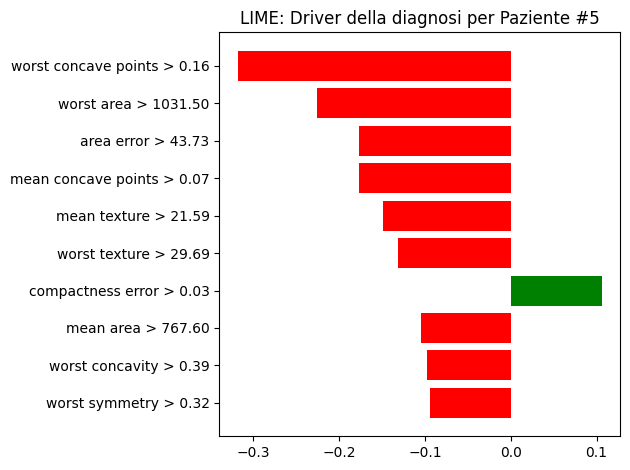

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import lime
import lime.lime_tabular

# 1. CARICAMENTO DATI
data = load_breast_cancer()
# Creiamo un DataFrame per le feature (X) e un array per il target (y)
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target 

# Split (X_test rimarrà un DataFrame, y_test sarà un array NumPy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. ADDESTRAMENTO XGBOOST
model_cancer = XGBClassifier(n_estimators=100, max_depth=3, random_state=42)
model_cancer.fit(X_train, y_train)

# Predizioni per il test set
y_pred = model_cancer.predict(X_test)

# 3. INIZIALIZZAZIONE LIME EXPLAINER
# Poiché il dataset è puramente numerico, non servono wrapper complessi
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=data.target_names.tolist(),
    mode='classification',
    random_state=42
)

# 4. SPIEGAZIONE DI UN CASO SPECIFICO
idx = 5 # Scegliamo il paziente all'indice 5
# X_test è un DataFrame, usiamo .iloc per estrarre la riga e .values per l'array
sample = X_test.iloc[idx].values 

exp = explainer.explain_instance(
    sample, 
    model_cancer.predict_proba, 
    num_features=10
)

# 5. VISUALIZZAZIONE CORRETTA (Senza errori .iloc)
print(f"--- ANALISI DIAGNOSTICA PAZIENTE #{idx} ---")
# Usiamo [idx] per l'array y_test e y_pred
print(f"Classe Reale: {data.target_names[y_test[idx]]}") 
print(f"Predizione Modello: {data.target_names[y_pred[idx]]}")

# Grafico LIME
exp.as_pyplot_figure()
plt.title(f"LIME: Driver della diagnosi per Paziente #{idx}")
plt.tight_layout()
plt.show()

Questo grafico è la "scatola nera" aperta: ti sta mostrando esattamente **perché** il modello ha preso una decisione specifica per il **Paziente #5**.

Mentre l'accuratezza generale ci dice se il modello è bravo, LIME ci dice se il modello è **ragionevole**. Ecco come interpretare ogni elemento:

---

### 1. Il Concetto: Spiegazione Locale

Questo non è un grafico dell'importanza generale di tutte le variabili. È un'analisi **locale**: si riferisce solo ed esclusivamente a questo paziente. Il modello dice: *"Ho deciso che questo caso è [Maligno/Benigno] a causa di questi fattori specifici riscontrati in questo individuo"*.

### 2. I Colori: La "Lotta" tra le Classi

Il grafico rappresenta un tiro alla fune tra due diagnosi:

* **Barre Rosse (Valori Negativi):** Rappresentano i fattori che spingono la predizione verso la **Classe 0 (Maligno)**. Più la barra è lunga verso sinistra, più quel fattore è un "segnale d'allarme" per il modello.
* **Barre Verdi (Valori Positivi):** Rappresentano i fattori che spingono verso la **Classe 1 (Benigno)**. Sono i segnali di "normalità" che bilanciano il giudizio.

### 3. L'Asse Y: Caratteristiche e Condizioni

A sinistra vedi la variabile e la condizione che ha attivato quel peso:

* **`worst concave points > 0.16`**: Questa è la variabile più importante per questo paziente. Il fatto che il valore sia superiore a 0.16 è un fortissimo indicatore di malignità (barra rossa molto lunga).
* **`compactness error > 0.03`**: Al contrario, questa caratteristica (essendo verde) è l'unica che suggerisce una natura benigna, ma il suo peso è piccolo rispetto alla valanga di segnali rossi.

### 4. L'Asse X: Il Peso (Impact)

I numeri in basso (0, -0.1, -0.2, ecc.) indicano quanto quella singola caratteristica ha spostato la **probabilità finale**.

* Se sommassi tutti questi pesi partendo da una "base" media, otterresti la probabilità finale calcolata da XGBoost.

---

### Verdetto per il Paziente #5

In questo caso specifico, il modello è **molto convinto** che il tumore sia **Maligno**.

Quasi tutti i driver principali (punti concavi, area, errore dell'area, texture) superano soglie critiche che il modello associa alla malignità. L'unico elemento "rassicurante" è l'errore di compattezza, ma è troppo debole per cambiare l'esito finale.

> **Nota da Data Scientist:** Se fossi un medico, guardando questo grafico diresti: *"Il modello ha deciso che è maligno soprattutto perché i punti concavi e l'area totale sono troppo elevati"*. Questa trasparenza permette di verificare che il modello non stia decidendo in base a fattori casuali.

---

## E le reti neurali?

Model: "BreastCancer_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6621 - loss: 0.6279 - val_accuracy: 0.9121 - val_loss: 0.4277
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9286 - loss: 0.3108 - val_accuracy: 0.9451 - val_loss: 0.1702
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9423 - loss: 0.1523 - val_accuracy: 0.9560 - val_loss: 0.1138
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9588 - loss: 0.0989 - val_accuracy: 0.9670 - val_loss: 0.0917
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9753 - loss: 0.0804 - val_accuracy: 0.9780 - val_loss: 0.0840
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9780 - loss: 0.0615 - val_accuracy: 0.9780 - val_loss: 0.0841
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9835 - loss: 0.0530 - val_accuracy: 0.9780 - val_loss: 0.0890
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9835 - loss: 0.0624 - val_accuracy: 0.9670 - v

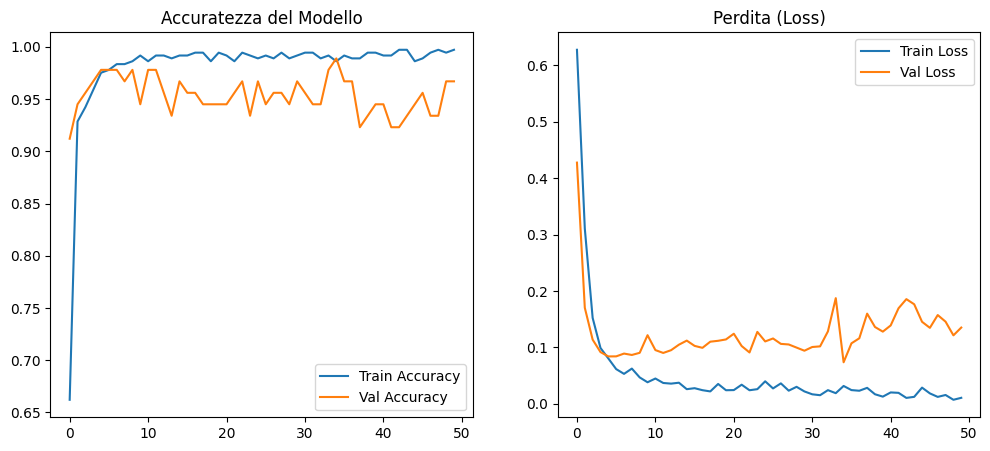

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9825 - loss: 0.1092

Accuratezza sul Test Set: 0.9825


In [ ]:
import os

# Configurazione obbligatoria: va fatta PRIMA di importare keras
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers, ops
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Caricamento e Scaling
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Definizione dell'Architettura
def build_cancer_model(input_shape):
    # Strato di Input
    inputs = keras.Input(shape=(input_shape,))
    
    # Primo strato denso con Dropout per evitare overfitting
    x = layers.Dense(16, activation="relu")(inputs)
    x = layers.Dropout(0.2)(x)
    
    # Secondo strato denso
    x = layers.Dense(8, activation="relu")(x)
    
    # Output: 1 neurone con Sigmoid per probabilità 0-1
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    # Creazione del modello
    model = keras.Model(inputs=inputs, outputs=outputs, name="BreastCancer_MLP")
    return model

model = build_cancer_model(X_train.shape[1])
model.summary()


# 3. Compilazione
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# 4. Training
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


# 5. Grafico delle Performance
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_df['accuracy'], label='Train Accuracy')
plt.plot(history_df['val_accuracy'], label='Val Accuracy')
plt.title('Accuratezza del Modello')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history_df['loss'], label='Train Loss')
plt.plot(history_df['val_loss'], label='Val Loss')
plt.title('Perdita (Loss)')
plt.legend()

plt.show()

# Valutazione finale
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nAccuratezza sul Test Set: {test_acc:.4f}")

Immagina la tua rete neurale come una gigantesca squadra di tiro con l'arco, dove ogni arciere (neurone) passa la freccia a quello successivo. La **Backpropagation** è essenzialmente il "feedback dell'allenatore" che, dopo ogni tiro, torna indietro lungo la fila per dire a ogni arciere esattamente come regolare la mira.

Ecco come avviene la magia, suddivisa in passaggi logici.

---

### 1. Il Forward Pass (La Profezia)

Prima di imparare, la rete deve "tirare". I dati entrano dall'input e viaggiano attraverso i vari strati. Ogni neurone esegue un calcolo semplice:

1. Moltiplica l'input per un **peso** ().
2. Aggiunge un **bias** ().
3. Passa il risultato attraverso una **funzione di attivazione** (come la ReLU).

Il risultato finale è la predizione .

---

### 2. Il Calcolo della Perdita (L'Errore)

Una volta ottenuta la predizione, la confrontiamo con il valore reale () usando una **Loss Function** (funzione di perdita). Per la classificazione, usiamo spesso la *Binary Cross-Entropy*:

$$Loss = -(y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}))$$

Se il valore è alto, significa che la rete ha sbagliato di grosso. Se è vicino allo zero, l'arciere ha quasi centrato il bersaglio.

---

### 3. Backpropagation: La Catena della Colpa

Qui inizia la vera danza. La Backpropagation risponde alla domanda: *"Quanto è colpa di questo specifico peso () se l'errore finale è così alto?"*.

Per farlo, usiamo la **Regola della Catena** (Chain Rule) del calcolo infinitesimale. Partiamo dall'errore alla fine e torniamo indietro calcolando le derivate parziali. In termini matematici, vogliamo trovare il **gradiente** della Loss rispetto a ogni peso:

$$\frac{\partial Loss}{\partial w} = \frac{\partial Loss}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w}$$

> **In parole povere:** Se sposto questo peso di un millimetro, di quanto si sposta la freccia sul bersaglio?

---

### 4. L'Ottimizzazione (Il Correttore)

Una volta che sappiamo "di chi è la colpa" (abbiamo i gradienti), entra in gioco l'ottimizzatore (come **Adam** o lo **Stochastic Gradient Descent**). L'ottimizzatore aggiorna i pesi nella direzione opposta al gradiente per scendere lungo la "valle" dell'errore:

$$w_{new} = w_{old} - \eta \cdot \nabla Loss$$

Dove $\eta$ è il **Learning Rate** (quanto è grande il passo che facciamo).

---

### In sintesi: Il Ciclo della Conoscenza

1. **Forward:** La rete spara la sua ipotesi.
2. **Loss:** Misuriamo quanto siamo andati lontano dal centro.
3. **Backpropagation:** Calcoliamo il contributo di ogni neurone all'errore (dal fondo all'inizio).
4. **Update:** Regoliamo i pesi per fare meglio al prossimo giro.



L'**overfitting** è il "peccato originale" del Machine Learning. In termini teorici, accade quando il tuo modello smette di imparare i pattern generali e inizia a **memorizzare il rumore** e le fluttuazioni casuali del training set.

Immagina uno studente che, invece di capire le regole della matematica, decidesse di **imparare a memoria** tutte le soluzioni del libro di testo. Se l'esame contiene esattamente le stesse domande del libro, prenderà 10. Ma se il professore cambia anche solo un numero, lo studente fallirà miseramente perché non ha capito la logica sottostante.

---

### 1. Il Segnale vs Il Rumore

In ogni dataset esistono due componenti:

1. **Il Segnale:** La relazione reale tra le caratteristiche (es. "un raggio cellulare grande è spesso legato a un tumore maligno").
2. **Il Rumore:** Errori di misurazione, casualità o casi isolati che non rappresentano la realtà generale.

Un modello in overfitting è **troppo flessibile**: ha troppi parametri (neuroni/pesi) e "si modella" attorno a ogni singolo punto del training set, includendo anche il rumore.

---

### 2. Il Bias-Variance Tradeoff

L'overfitting è strettamente legato al concetto di **Varianza**:

* **Underfitting (Alto Bias):** Il modello è troppo semplice (es. una retta per dati curvi). Sbaglia sia sul training che sul test.
* **Overfitting (Alta Varianza):** Il modello è troppo complesso. Ha un errore quasi nullo sul training set, ma l'errore esplode non appena vede dati nuovi (**Validation/Test set**).

Matematicamente, cerchiamo di minimizzare l'errore totale, che è composto da:


---

### 3. Perché accade nelle Reti Neurali?

Le reti neurali sono particolarmente inclini all'overfitting perché sono "approssimatori universali": data abbastanza potenza (neuroni ed epoche), possono imparare qualsiasi funzione, anche una puramente casuale.

Le cause principali sono:

* **Troppe Epoche:** La rete continua ad aggiornare i pesi tramite backpropagation anche quando ha già imparato il segnale, iniziando a scavare nel rumore.
* **Modello troppo profondo:** Troppi neuroni rispetto alla quantità di dati disponibili.
* **Dataset piccolo:** La rete non ha abbastanza esempi per distinguere ciò che è una regola generale da ciò che è un'eccezione.

---

### 4. Come si riconosce?

Basta guardare le curve di addestramento che abbiamo generato prima:

* Se la **Training Loss** scende verso lo zero...
* ...ma la **Validation Loss** inizia a risalire dopo un certo punto...
* **Ecco l'overfitting.** In quel preciso istante, la rete ha smesso di imparare e ha iniziato a memorizzare.

---

### 5. Le "Cure" (Regolarizzazione)

Per evitare che la rete "studi a memoria", usiamo diverse tecniche:

1. **Early Stopping:** Fermiamo l'allenatore non appena la Validation Loss smette di scendere.
2. **Dropout:** Spegniamo casualmente alcuni neuroni durante il training. Questo costringe la rete a non fare affidamento su singoli neuroni, ma a distribuire la conoscenza (creando ridondanza).
3. **Regolarizzazione L1/L2:** Aggiungiamo una "penalità" alla funzione di costo per evitare che i pesi diventino troppo grandi e complessi.



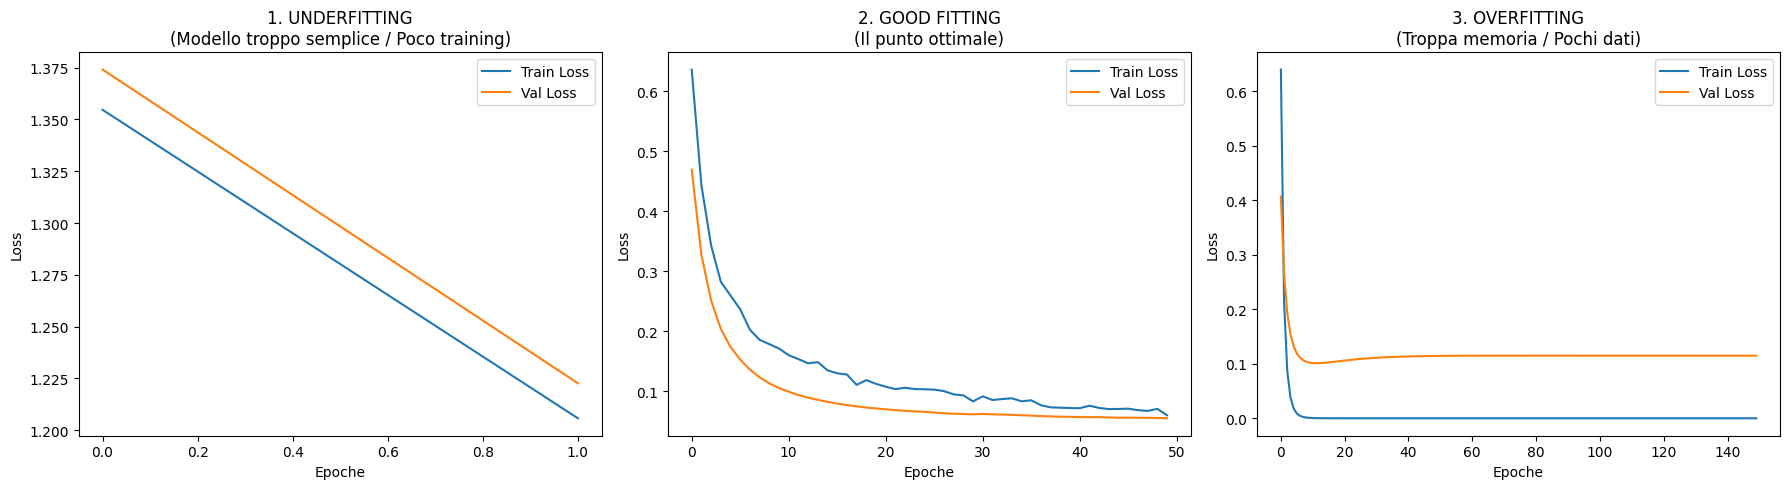

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. PREPARAZIONE DATI ---
data = load_breast_cancer()
X, y = data.data, data.target
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test = scaler.transform(X_test)

# Funzione di utility per il plot
def plot_history(history, title):
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title)
    plt.xlabel('Epoche')
    plt.ylabel('Loss')
    plt.legend()

plt.figure(figsize=(18, 5))

# --- 2. SCENARIO 1: UNDERFITTING ---
# Una rete con un solo neurone e addestrata per sole 2 epoche
inputs = keras.Input(shape=(30,))
outputs = layers.Dense(1, activation='sigmoid')(inputs)
model_under = keras.Model(inputs, outputs)
model_under.compile(optimizer='adam', loss='binary_crossentropy')

history_under = model_under.fit(X_train_full, y_train_full, validation_data=(X_test, y_test), 
                                epochs=2, verbose=0)

plt.subplot(1, 3, 1)
plot_history(history_under, "1. UNDERFITTING\n(Modello troppo semplice / Poco training)")

# --- 3. SCENARIO 2: GOOD FITTING ---
# Una rete bilanciata con dropout e un numero congruo di epoche
inputs = keras.Input(shape=(30,))
x = layers.Dense(16, activation='relu')(inputs)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_good = keras.Model(inputs, outputs)
model_good.compile(optimizer='adam', loss='binary_crossentropy')

history_good = model_good.fit(X_train_full, y_train_full, validation_data=(X_test, y_test), 
                              epochs=50, verbose=0)

plt.subplot(1, 3, 2)
plot_history(history_good, "2. GOOD FITTING\n(Il punto ottimale)")

# --- 4. SCENARIO 3: OVERFITTING ---
# Una rete enorme (1024 neuroni) addestrata su pochissimi dati (solo 10 campioni)
# Questo forza la rete a memorizzare quei 10 esempi perfettamente.
X_train_tiny = X_train_full[:10]
y_train_tiny = y_train_full[:10]

inputs = keras.Input(shape=(30,))
x = layers.Dense(1024, activation='relu')(inputs)
x = layers.Dense(512, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_over = keras.Model(inputs, outputs)
model_over.compile(optimizer='adam', loss='binary_crossentropy')

history_over = model_over.fit(X_train_tiny, y_train_tiny, validation_data=(X_test, y_test), 
                             epochs=150, verbose=0)

plt.subplot(1, 3, 3)
plot_history(history_over, "3. OVERFITTING\n(Troppa memoria / Pochi dati)")

plt.tight_layout()
plt.show()


### Cos'è il Dropout?

In una rete neurale standard, tutti i neuroni sono connessi tra loro. Durante l'addestramento, alcuni neuroni possono diventare "pigri" o troppo dipendenti da altri, creando quelle che chiamiamo **co-adattamenti complessi**. In pratica, la rete impara a fare affidamento solo su pochi percorsi specifici, ignorando il resto e finendo per memorizzare il rumore dei dati.

Il **Dropout** rompe questo schema: durante ogni passo dell'addestramento, "spegne" casualmente una percentuale di neuroni (tipicamente tra il **20%** e il **50%**).

---

### Come funziona (La Teoria)

Per ogni batch di dati che passa attraverso la rete:

1. Viene lanciata una moneta (distribuzione di Bernoulli) per ogni neurone dello strato in cui è attivo il Dropout.
2. Se il risultato è "croce", il neurone viene **disattivato** (il suo output è forzato a **0**).
3. I pesi di quel neurone non vengono aggiornati durante il passaggio di backpropagation di quel turno.

Matematicamente, per un neurone con output , il Dropout applica una maschera :

$$y = m \cdot x$$

Dove $m$ è una variabile casuale che vale $0$ con probabilità $p$ e $1$ con probabilità $1-p$.

---

### L'Analogia della Squadra di Calcio

Immagina una squadra di calcio che si affida sempre e solo al suo fuoriclasse. Se il fuoriclasse sta male, la squadra non sa più cosa fare.
Se l'allenatore, durante gli allenamenti, obbligasse casualmente dei giocatori a sedersi in panchina, costringerebbe tutti gli altri a imparare a crossare, difendere e segnare.

**Il risultato?** Una squadra molto più robusta e versatile, dove ogni giocatore sa cavarsela da solo.

---

### Perché si usa?

* **Riduce l'Overfitting:** Impedisce alla rete di memorizzare i dati di training.
* **Migliora la Robustezza:** Forza la rete a trovare pattern più generali e distribuiti su tutti i neuroni.
* **Simula un "Ensemble":** Addestrare una rete con Dropout è come addestrare migliaia di reti diverse e leggermente più piccole contemporaneamente, per poi "fonderle" insieme al momento del test.

> **Nota importante:** Il Dropout si attiva **solo durante il training**. Quando usi il modello per fare predizioni (test/inferenza), tutti i neuroni sono accesi per dare la massima precisione possibile.

---

### Come si scrive nel codice (Keras Functional API)

Riprendendo il nostro modello per il *Breast Cancer*, ecco dove si inserisce:

```python
from keras import layers

def build_model_with_dropout(input_shape):
    inputs = keras.Input(shape=(input_shape,))
    
    # Primo strato denso
    x = layers.Dense(64, activation="relu")(inputs)
    
    # Applichiamo il Dropout: spegniamo il 30% dei neuroni del livello precedente
    x = layers.Dropout(0.3)(x) 
    
    x = layers.Dense(32, activation="relu")(x)
    
    # Un altro strato di Dropout per sicurezza
    x = layers.Dropout(0.2)(x)
    
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    return keras.Model(inputs, outputs)

```

---

### Quando NON usarlo?

Non è sempre necessario. Se hai milioni di dati e una rete piccola, l'overfitting non è un problema e il Dropout potrebbe rallentare inutilmente l'apprendimento. Si usa principalmente quando la rete è molto capace (tanti neuroni) rispetto alla quantità di dati disponibili.



In [ ]:
import os

# 1. SET BACKEND: Comunichiamo a Keras di usare PyTorch invece di TensorFlow
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import layers
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. PREPARAZIONE DATI (Standard per Reti Neurali)
data = load_breast_cancer()
X, y = data.data, data.target

# Split in Training e Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling: Fondamentale per far convergere i pesi della rete (Backpropagation)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. COSTRUZIONE MODELLO (Functional API)
def build_network():
    # Definiamo l'ingresso (shape=30 perché abbiamo 30 feature nel dataset)
    inputs = keras.Input(shape=(30,), name="strato_input")
    
    # Primo strato: 64 neuroni, attivazione ReLU (evita il vanishing gradient)
    x = layers.Dense(64, activation="relu", name="denso_1")(inputs)
    
    # DROPOUT: "Spegniamo" casualmente il 30% dei neuroni per evitare l'Overfitting
    # Costringe la rete a non memorizzare i dati, ma a imparare pattern generali
    x = layers.Dropout(0.3)(x)
    
    # Secondo strato: 32 neuroni
    x = layers.Dense(32, activation="relu", name="denso_2")(x)
    
    # Output: 1 neurone con Sigmoid per ottenere una probabilità tra 0 e 1
    outputs = layers.Dense(1, activation="sigmoid", name="output")(x)
    
    # Creiamo l'oggetto Modello collegando Input e Output
    model = keras.Model(inputs=inputs, outputs=outputs, name="Neural_Clinician")
    return model

model = build_network()

# 4. COMPILAZIONE (Definiamo le regole del gioco)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001), # Algoritmo di ottimizzazione
    loss="binary_crossentropy",                         # Funzione di perdita per classificazione binaria
    metrics=["accuracy"]                                # Metrica per monitorare le performance
)

# 5. TRAINING CON EARLY STOPPING
# L'allenatore ferma l'addestramento se la Validation Loss smette di migliorare per 5 epoche
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True
)

print("[INFO] Addestramento in corso su Backend PyTorch...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# 6. VALUTAZIONE FINALE
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n--- PERFORMANCE ---")
print(f"Accuratezza finale sul Test Set: {acc:.4f}")

# 7. PREDIZIONE
# Esempio: prendiamo il primo paziente del test set
pred_prob = model.predict(X_test[:1], verbose=0)
print(f"Probabilità che il tumore sia Benigno (Classe 1): {pred_prob[0][0]:.2%}")

[INFO] Addestramento in corso su Backend PyTorch...
Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6538 - loss: 0.6011 - val_accuracy: 0.8791 - val_loss: 0.3401
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9341 - loss: 0.2780 - val_accuracy: 0.9231 - val_loss: 0.2067
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9643 - loss: 0.1645 - val_accuracy: 0.9560 - val_loss: 0.1573
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9670 - loss: 0.1359 - val_accuracy: 0.9560 - val_loss: 0.1342
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9753 - loss: 0.1047 - val_accuracy: 0.9560 - val_loss: 0.1222
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9725 - loss: 0.0958 - val_accuracy: 0.9670 - val_loss: 0.1144
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9725 - loss: 0.0845 - val_accuracy: 0.9670 - val_loss: 0.1067
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 

In [133]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Caricamento del dataset
housing = fetch_california_housing()

# Creazione del DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # Il target è espresso in unità di 100.000$

print(f"Dimensioni del dataset: {df.shape}")
print("\nPrime 5 righe:")
print(df.head())

Dimensioni del dataset: (20640, 9)

Prime 5 righe:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0   8.325      41.0     6.984      1.024       322.0     2.556     37.88   
1   8.301      21.0     6.238      0.972      2401.0     2.110     37.86   
2   7.257      52.0     8.288      1.073       496.0     2.802     37.85   
3   5.643      52.0     5.817      1.073       558.0     2.548     37.85   
4   3.846      52.0     6.282      1.081       565.0     2.181     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [134]:
import pandas as pd

import numpy as np

from sklearn.datasets import fetch_california_housing
 
# 1. Carichiamo il dataset

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df['MedHouseVal'] = housing.target
 
print(f"Righe totali prima: {len(df)}")
 
# 2. Identificazione e rimozione degli outlier

# Calcoliamo la media e la deviazione standard per ogni colonna

# Escludiamo eventuali colonne categoriche se presenti (qui sono tutte numeriche)

numeric_df = df.select_dtypes(include=[np.number])
 
# Applichiamo il filtro: teniamo solo i punti che sono entro 3 deviazioni standard

df_clean = df[((numeric_df - numeric_df.mean()).abs() <= 3 * numeric_df.std()).all(axis=1)]
 
print(f"Righe totali dopo: {len(df_clean)}")

print(f"Righe rimosse: {len(df) - len(df_clean)}")
 
# 3. Verifica rapida

print("\nStatistiche descrittive (AveRooms) prima e dopo:")

print(f"Max prima: {df['AveRooms'].max():.2f}")

print(f"Max dopo:  {df_clean['AveRooms'].max():.2f}")
 

Righe totali prima: 20640
Righe totali dopo: 19794
Righe rimosse: 846

Statistiche descrittive (AveRooms) prima e dopo:
Max prima: 141.91
Max dopo:  12.45
